# 0.准备各种包、定义函数、数据文件夹等

In [2]:
import os
import typing
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import collections
import math
import scipy.stats
from scipy.stats import gaussian_kde, variation
from scipy.stats import pearsonr
import sys
from PIL import Image

In [3]:
%matplotlib inline
default_pal = sns.color_palette()
from scipy.stats import gaussian_kde, pearsonr

In [4]:
%config InlineBackend.figure_format = 'retina'
from scipy import stats
import numpy as np
from scipy.stats import mannwhitneyu

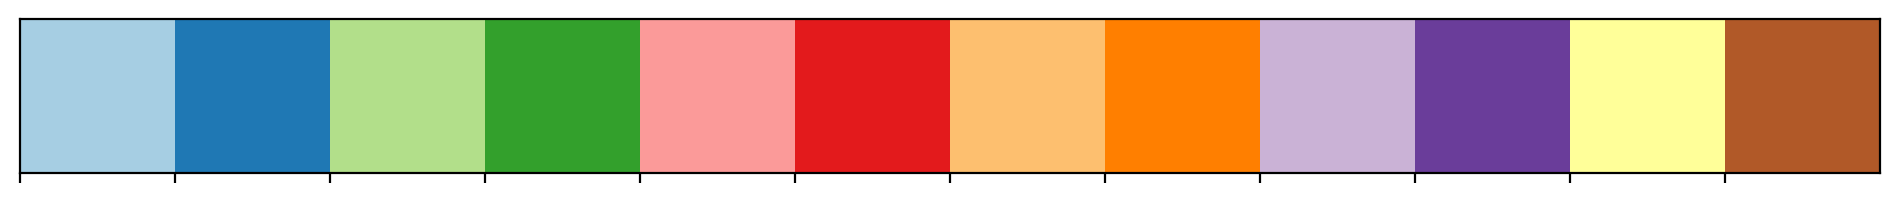

In [5]:
# setting color palette
import seaborn as sns
pal = sns.color_palette('Paired')
#pal = [pal[i] for i in (0,1, 6,7, 8 ,9,2 ,3)]
#pal = [pal[i] for i in (1, 7, 9 ,3)]
sns.set_palette(pal)
sns.palplot(pal)

In [6]:
import pickle

# 1.polya的分布范围

In [7]:
def lp(pkl):
    with open(pkl, "rb") as fh:
        data = pickle.load(fh)
    return data

In [8]:
data_frames=lp("/data/Zhaijx/cheny/project/04.polyA_evo/12.all_pep/pepid_polya/all_species.pep.pickle")

In [ ]:
data_frames_median=lp("/data/Zhaijx/cheny/project/04.polyA_evo/12.all_pep/pepid_polya_median/all_species.pep_median.pickle")

In [14]:
polya_data = []
for key in data_frames.keys():
    df = data_frames[key]
    polya_length = df[['polya_length','species']]
    polya_data.append(polya_length)
new_df = pd.concat(polya_data, ignore_index=True)

In [15]:
new_df = new_df[new_df['polya_length'] > 10]

In [ ]:
species_order = ['Chrei', 'Phpat', 'Semoe', 'Adcap', 'Cypan', 'Cydeb', 'Nycol', 'Mabio', 'Phequ', 'Zemay', 'Orsat', 'Maint', 'Vivin', 'Artha', 'Glmax', 'Cusat', 'Bevul', 'Imgla', 'Solyc', 'Lasat']


In [ ]:
new_df['species'] = pd.Categorical(new_df['species'], categories=species_order, ordered=True)

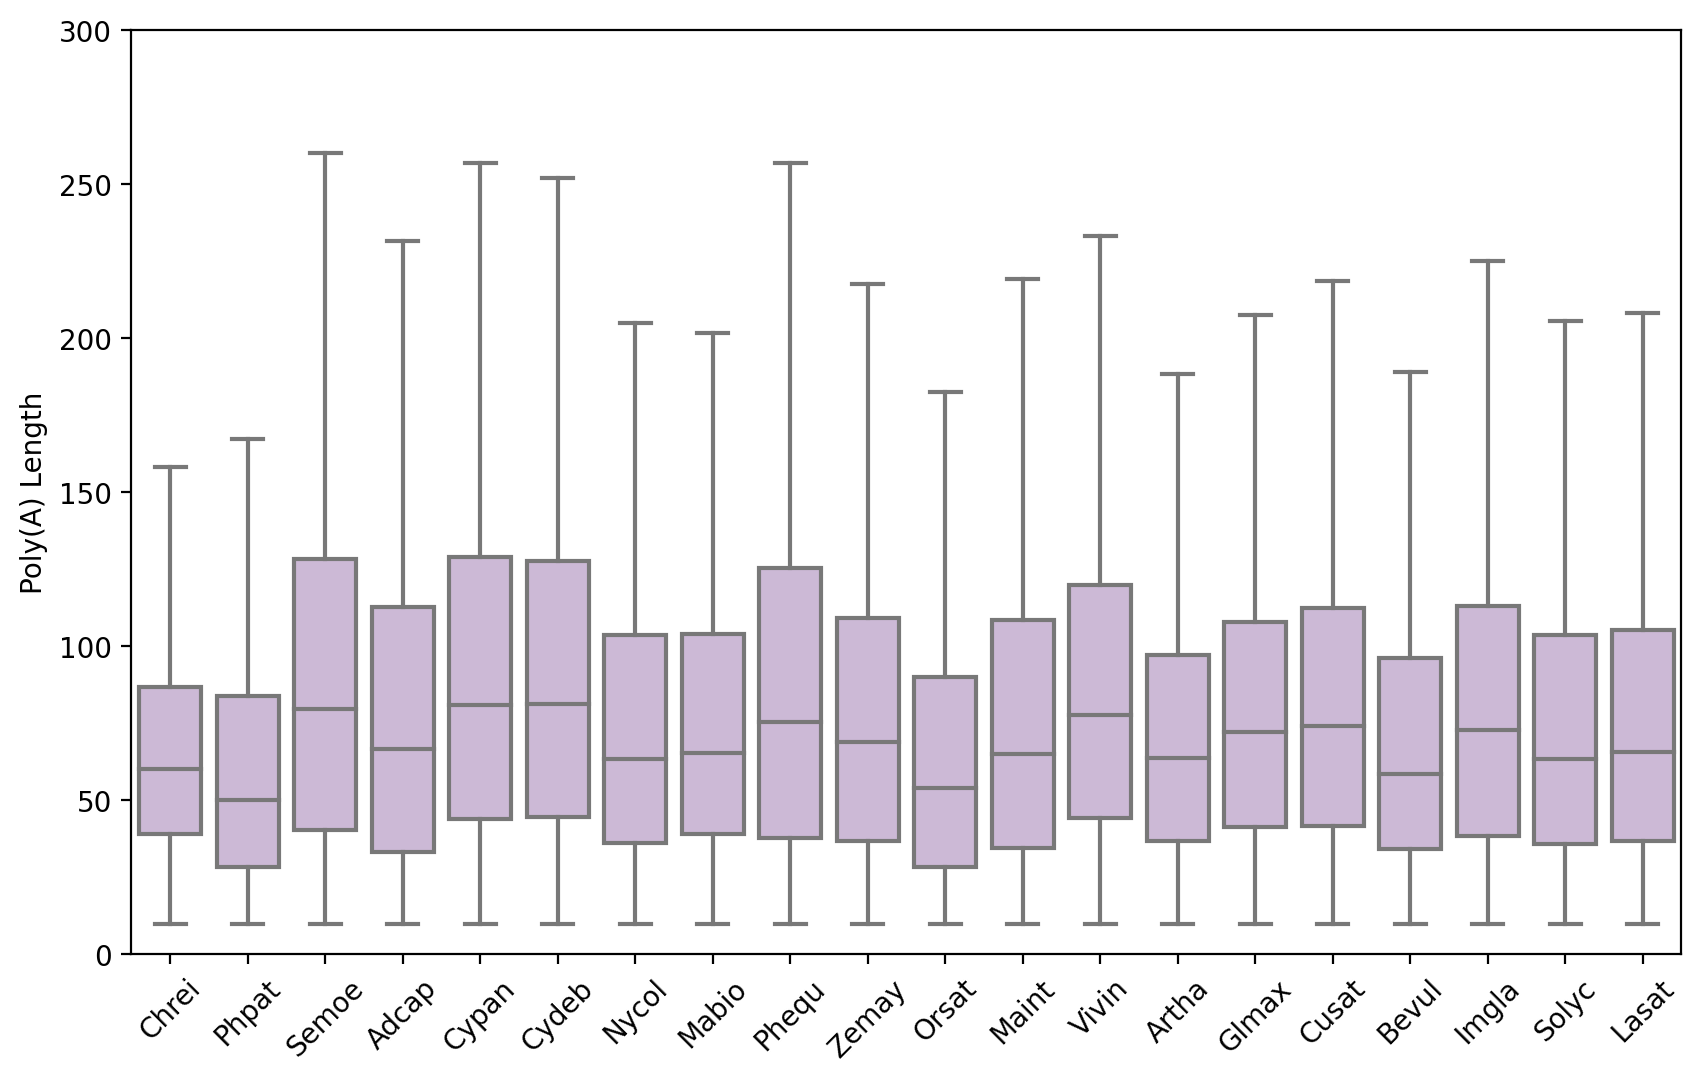

In [ ]:
plt.figure(figsize=(10, 6))  # 设置图形的大小
sns.boxplot(x='species', y='polya_length', data=new_df,showfliers=False,color='#cdb4db')
plt.title('')
plt.suptitle('')  # 去掉默认的副标题
plt.xlabel('')
plt.xticks(rotation=45)
plt.ylabel('Poly(A) Length')
plt.ylim(0,300)
plt.rcParams['svg.fonttype']='none'
plt.savefig("03.stat/1.13.range/range.svg",format='svg')
plt.show()


## 1.2 >170 nt 的比例


In [83]:
total_170_nt=pd.DataFrame()
for species in data_frames.keys():
    species_data = data_frames.get(species)
    species_data = species_data[species_data['polya_length'] > 10]
    percentage = (species_data['polya_length'] > 170).sum() / len(species_data) * 100
    test = pd.DataFrame({'species': [species],'percentage_of_170nt': [percentage]})
    total_170_nt = pd.concat([total_170_nt, test], ignore_index=True)

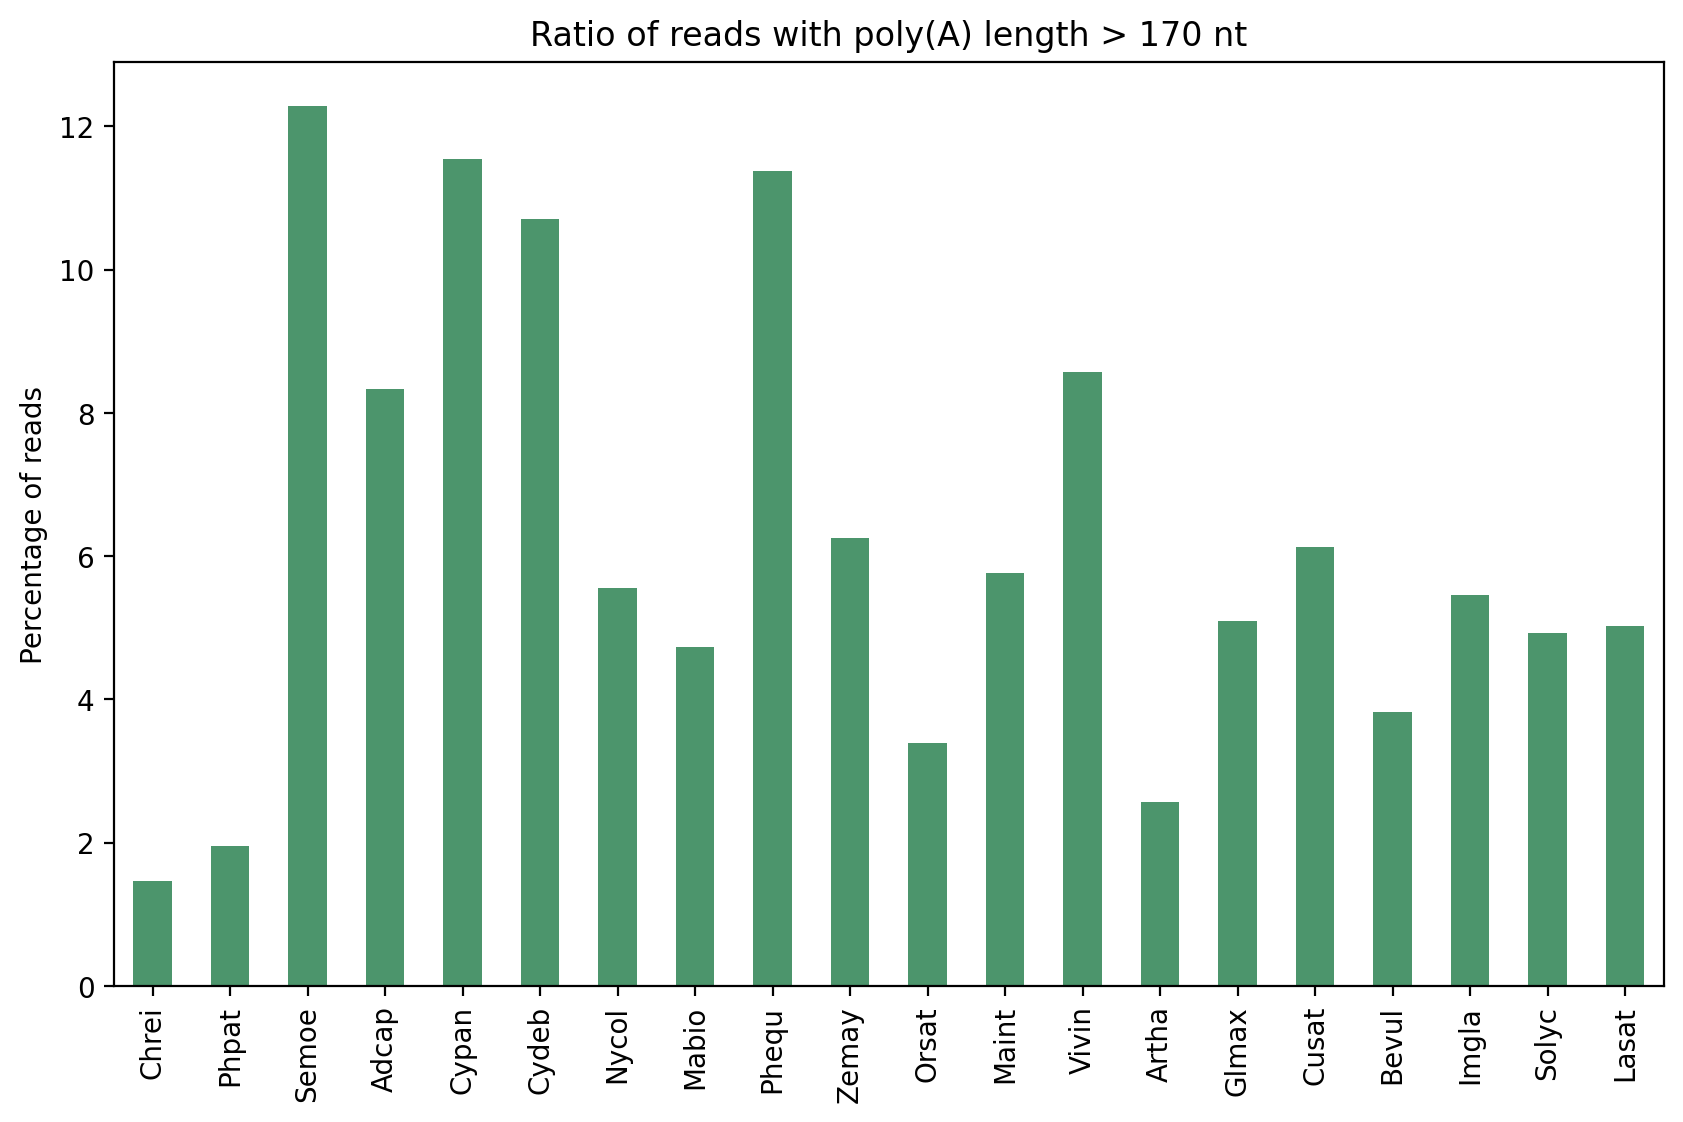

In [ ]:
#简化物种名字
x_order = ['Chrei', 'Phpat', 'Semoe', 'Adcap', 'Cypan', 'Cydeb', 'Nycol', 'Mabio', 'Phequ', 'Zemay', 'Orsat', 'Maint', 'Vivin', 'Artha', 'Glmax', 'Cusat', 'Bevul', 'Imgla', 'Solyc', 'Lasat']
total_170_nt = total_170_nt.set_index('species').reindex(x_order).reset_index()

# 画柱状图并移除图例
ax = total_170_nt.plot(kind='bar', x='species', y='percentage_of_170nt', figsize=(10, 6), title='Ratio of reads with poly(A) length > 170 nt', legend=False,color='#4c956c')
ax.set_ylabel("Percentage of reads") 
ax.set_xlabel("")  # 设置横轴标签
plt.rcParams['svg.fonttype']='none'
plt.savefig("03.stat/1.13.range/170nt.svg",format='svg')
plt.show()  #显示图形

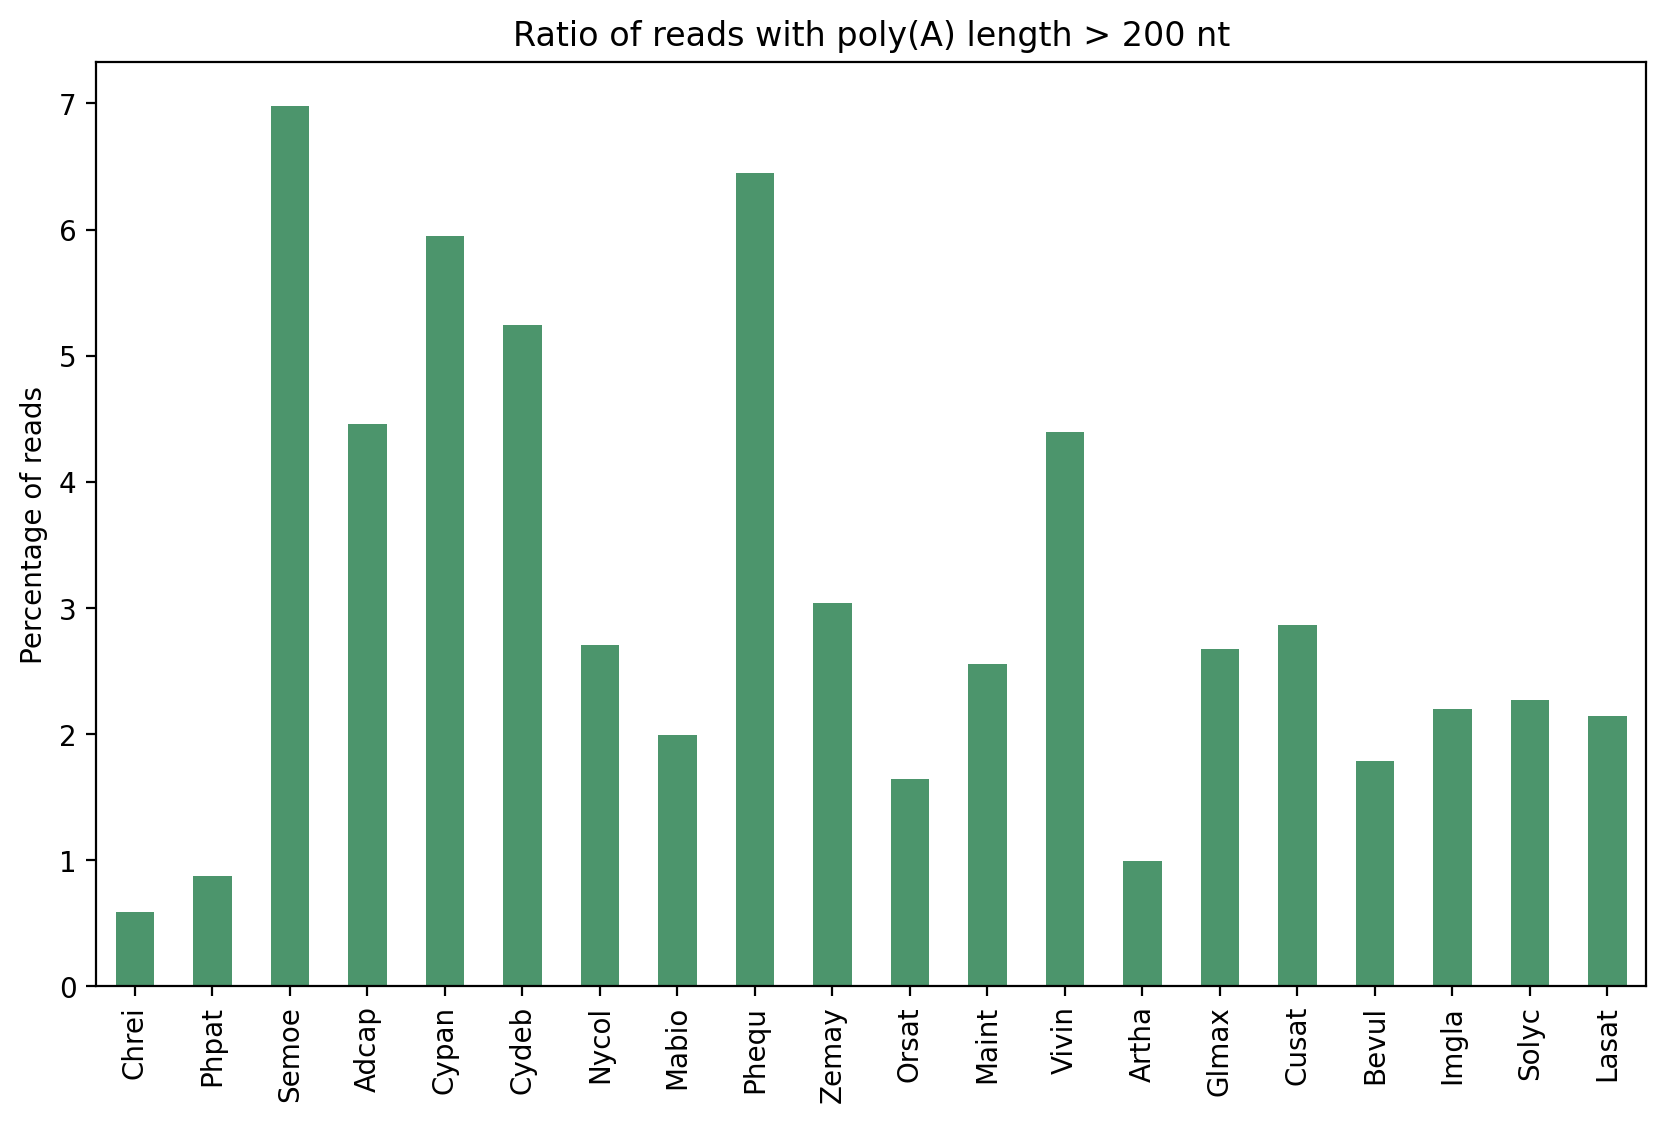

In [86]:
total_170_nt=pd.DataFrame()
for species in data_frames.keys():
    species_data = data_frames.get(species)
    species_data = species_data[species_data['polya_length'] > 10]
    percentage = (species_data['polya_length'] > 200).sum() / len(species_data) * 100
    test = pd.DataFrame({'species': [species],'percentage_of_170nt': [percentage]})
    total_170_nt = pd.concat([total_170_nt, test], ignore_index=True)
#简化物种名字
x_order = ['Chrei', 'Phpat', 'Semoe', 'Adcap', 'Cypan', 'Cydeb', 'Nycol', 'Mabio', 'Phequ', 'Zemay', 'Orsat', 'Maint', 'Vivin', 'Artha', 'Glmax', 'Cusat', 'Bevul', 'Imgla', 'Solyc', 'Lasat']
total_170_nt = total_170_nt.set_index('species').reindex(x_order).reset_index()

# 画柱状图并移除图例
ax = total_170_nt.plot(kind='bar', x='species', y='percentage_of_170nt', figsize=(10, 6), title='Ratio of reads with poly(A) length > 200 nt', legend=False,color='#4c956c')
ax.set_ylabel("Percentage of reads") 
ax.set_xlabel("")  # 设置横轴标签
plt.rcParams['svg.fonttype']='none'
#plt.savefig("03.stat/1.13.range/170nt.svg",format='svg')
plt.show()  #显示图形

# 2.画图统计reads的尾巴分布

## 2.1 reads的A尾分布函数

In [9]:
#定义函数：绘制样本中reads的A尾分布的直方图，使用第一个数据框的数据
def plot_hist_samples_polya_length(xs,
                                   samples,
                                   bin_length=1,
                                   min_length=10, 
                                   max_length = 300, 
                                   figsize=None, 
                                   linewidth=2, 
                                   linestyle=None, 
                                   color=None, 
                                   plot_legend=True, 
                                   ax=None,
                                   xlab="Poly(A) tail length",
                                   ylab="Ratio of Reads"):
    
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        
    for sample, x in zip(samples, xs):
        x = x[(x >= min_length) & (x <= max_length)]
        w = np.ones(len(x)) / x.sum()
        ax.hist(
            x,
            bins = np.arange(min_length, max_length, bin_length),
            weights=w,
            histtype="step",
            label=sample,
            density=True,
            linewidth=linewidth,
            linestyle=linestyle,
            color=color
        )
        
    ax.set_ylim(0)
    ax.set_xlim(10, max_length)

    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    if plot_legend:
        plt.legend(bbox_to_anchor=[1, 0.5])

In [10]:
#定义函数，统计reads的尾长，按照长短的频次分布，进行频率的统计，并绘制成热图
#chatgpt
def plot_heatmap_read_length(x, 
                             bin_length=1,
                            min_length=10,
                            max_length=200,
                            cmap = "Blues", 
                            vmin=0,
                            vmax=None,
                            plot_legend=True,
                            title=None):
    
    tmp_bins = range(1, max_length+1, 1)
    x = x[(x>=min_length)]
    total_count = len(x)
    x = x[x<max_length]
    x = pd.Series(np.digitize(x, tmp_bins)).value_counts().sort_index()
    d = pd.DataFrame(x)
    d.columns = ["count"]
    d["length"] = d.index
    d = pd.DataFrame({"length": range(np.digitize(min_length, tmp_bins), 
                                      np.digitize(max_length-1, tmp_bins)+1, 
                                      1)}).merge(d, on="length", how="left").fillna(0)
    d.index = d["length"]
    d["count"] = d["count"]/total_count

    # Transpose the data for horizontal heatmap
    d_transposed = d[["count"]].T

    h = sns.clustermap(d_transposed, row_cluster=False, col_cluster=False, cmap=cmap, figsize=[2, 1], vmin=vmin, vmax=vmax)


    h.ax_heatmap.tick_params(right=False, bottom=False, labelright=False, labelbottom=False)
    #h.ax_heatmap.tick_params(bottom=False, labelbottom=False)
    h.ax_heatmap.set_xlabel("")
    h.ax_heatmap.set_ylabel("")
    if not plot_legend:
        h.cax.set_visible(False)
    if title is not None:
        ax = h.ax_heatmap  # Get the axes object       
        # Remove the original title
        ax.set_title("")
        # Determine the x and y coordinates for the new title
        x_coord = 1.05  # Adjust the value as needed
        y_coord = 0.5  # Adjust the value as needed       
        # Add the new title
        ax.text(x_coord, y_coord, title, transform=ax.transAxes, fontstyle='italic', fontsize=12, va='center')

In [11]:
#定义函数，主要根据mRNA列进行分组，即每个基因一组，统计其'polya_length'信息，包括个数、尾长的中位数和平均值
def stat_polya_length(df, columns=("mRNA", "n_read", "median_polya", "mean_polya")):
    stat_results = (df.groupby('mRNA')["polya_length"].
                      agg([len, np.median, np.mean]).
                      reset_index())
    if columns:
        stat_results.columns = columns
    return stat_results


#定义函数，根据reads的情况 计算到基因的分布上
def stat_all_ir_spliced_polya_length(df):
    #筛选A长度>10的reads
    df = df.query('polya_length >= 10')
    #上面那个函数，统计基因的A尾个数、长度中位数、平均数
    all_polya_length = stat_polya_length(df, ["mRNA", "all_n_read", "all_median_polya", "all_mean_polya"])
    #将mRNA分类三种尾情况。具有内含子保留的mRNA,没有内含子保留的为完全剪切。另外如果，type为“polya”表明是全长的mRNA。
    df_full_length = df.query('type == "polya"')
    df_ir = df_full_length.query('retention_introns != ""')
    df_spliced = df_full_length.query('retention_introns == ""')

    #对于内含子保留的mRNA，根据基因分组，统计A尾个数、长度中位数、平均数
    ir_polya_length = stat_polya_length(df_ir,
                                        ["mRNA", "ir_n_read", "ir_median_polya", "ir_mean_polya"])
    #对于完全剪切、没有内含子的mRNA，根据基因分组，统计A尾个数、长度中位数、平均数
    spliced_polya_length = stat_polya_length(df_spliced,
                                        ["mRNA", "spliced_n_read", "spliced_median_polya", "spliced_mean_polya"])
    #按照基因ID，合并整体A尾信息、具有内含子的序列的信息、完全剪切的序列的信息
    mRNA_polya_length = (all_polya_length.
                            merge(ir_polya_length, on="mRNA", how="left").
                            merge(spliced_polya_length, on="mRNA", how="left"))
    #空的地方用0填补
    mRNA_polya_length.fillna(0, inplace=True)

    #转换为整数
    for column in ["all_n_read", "ir_n_read", "spliced_n_read"]:
        mRNA_polya_length[column] = mRNA_polya_length[column].astype(int)
        
    return mRNA_polya_length


## 2.2作图 reads 热图


In [ ]:
x_order = ['01.Chrei', '02.Phpat', '03.Semoe', '04.Adcap', '05.Cypan', '06.Cydeb', '07.Nycol', '08.Mabio', '09.Phequ', 
'10.Zemay', '11.Orsat', '12.Maint', '13.Vivin', '14.Artha', '15.Glmax', '16.Cusat', '17.Bevul', '18.Imgla', '19.Solyc', '20.Lasat']

In [ ]:
for species in x_order:
    # 提取 key 名称
    key = species.split('.')[1]  # 提取 Chrei, Phpat 等
    if key in data_frames_median:
        df = data_frames[key]
        sample_name=''.join(key[i] for i in [0,2,3])
        plot_heatmap_read_length(df.polya_length,
                     vmin=0,vmax=0.012,
                     bin_length=1,
                     plot_legend=False,
                     cmap = "Blues",
                     title=sample_name)
        plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15))  
        plt.savefig(f"03.stat/1.2_reads_heatmap/new/{species}.png", dpi=300, bbox_inches='tight') 

In [ ]:
os.chdir("/1.2_reads_heatmap/new")
image_files = ['01.Chrei.png','02.Phpat.png','03.Semoe.png','04.Adcap.png','05.Cypan.png',
'06.Cydeb.png','07.Nycol.png','08.Mabio.png','09.Phequ.png','10.Zemay.png',
'11.Orsat.png','12.Maint.png','13.Vivin.png','14.Artha.png','15.Glmax.png',
'16.Cusat.png','17.Bevul.png','18.Imgla.png','19.Solyc.png','20.Lasat.png',]

combined_height = 0
combined_width = 0
images = []  # 存储 image 对象

for image_path in image_files:
    image = Image.open(image_path)
    combined_height += image.height
    combined_width = max(combined_width, image.width)
    images.append(image)  # 将打开的 image 对象添加到列表 images 中

combined_image = Image.new("RGB", (combined_width, combined_height), (255, 255, 255))

y_offset = 0
for image in images:  # 遍历 images 列表中的 image 对象
    width, height = image.size
    image = image.crop((0, 30, width, height - 30))
    combined_image.paste(image, (0, y_offset))
    y_offset += image.height

combined_image.save("combined.png")

## 2.3 read 分布曲线

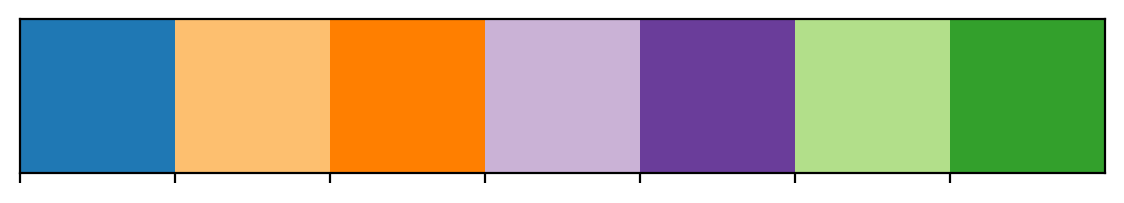

In [16]:
pal = sns.color_palette('Paired')
pal = [pal[i] for i in (1, 6,7, 8 ,9,2 ,3)]
sns.set_palette(pal)
sns.palplot(pal)

In [17]:
x_order = ['01.Chrei', '02.Phpat', '03.Semoe', '04.Adcap', '05.Cypan', '06.Cydeb', '07.Nycol', '08.Mabio', '09.Phequ', 
'10.Zemay', '11.Orsat', '12.Maint', '13.Vivin', '14.Artha', '15.Glmax', '16.Cusat', '17.Bevul', '18.Imgla', '19.Solyc', '20.Lasat']

In [ ]:
for species in x_order:
    # 提取 key 名称
    key = species.split('.')[1]  # 提取 Chrei, Phpat 等
    if key in data_frames:
        df = data_frames[key]
        df =df[df['polya_length'] > 10]
        sample_name=''.join(key[i] for i in [0,2,3])
        plot_hist_samples_polya_length(xs = [df.polya_length],
                                  samples = [sample_name],
                                  figsize = [3, 3],
                                  plot_legend = False)
        plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15)) 
        plt.savefig(f"03.stat/1.1_reads_hist/new/{species}.png", dpi=300, bbox_inches='tight') 

# 3.基因 median

## 3.1 median的柱状图

In [ ]:
def lp(pkl):
    with open(pkl, "rb") as fh:
        data = pickle.load(fh)
    return data

In [ ]:
data_frames_median=lp("12.all_pep/pepid_polya_median/all_species.pep_median.pickle")

In [ ]:
for species in x_order:
    # 提取 key 名称
    key = species.split('.')[1]  # 提取 Chrei, Phpat 等
    if key in data_frames_median:
        df = data_frames_median[key]
        df =df[df['all_n_read'] > 20]
        sample_name=''.join(key[i] for i in [0,2,3])
        plot_hist_samples_polya_length(xs = [df.all_median_polya],
                                  samples = [sample_name],
                                  color = "Orange",
                                  figsize = [3, 3],
                                  plot_legend = True,
                                  ylab="Ratio of genes",
                                  max_length = 300)
        plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15))  
        plt.savefig(f"03.stat/1.3_gene_hist/new/{species}.png", dpi=300, bbox_inches='tight') 

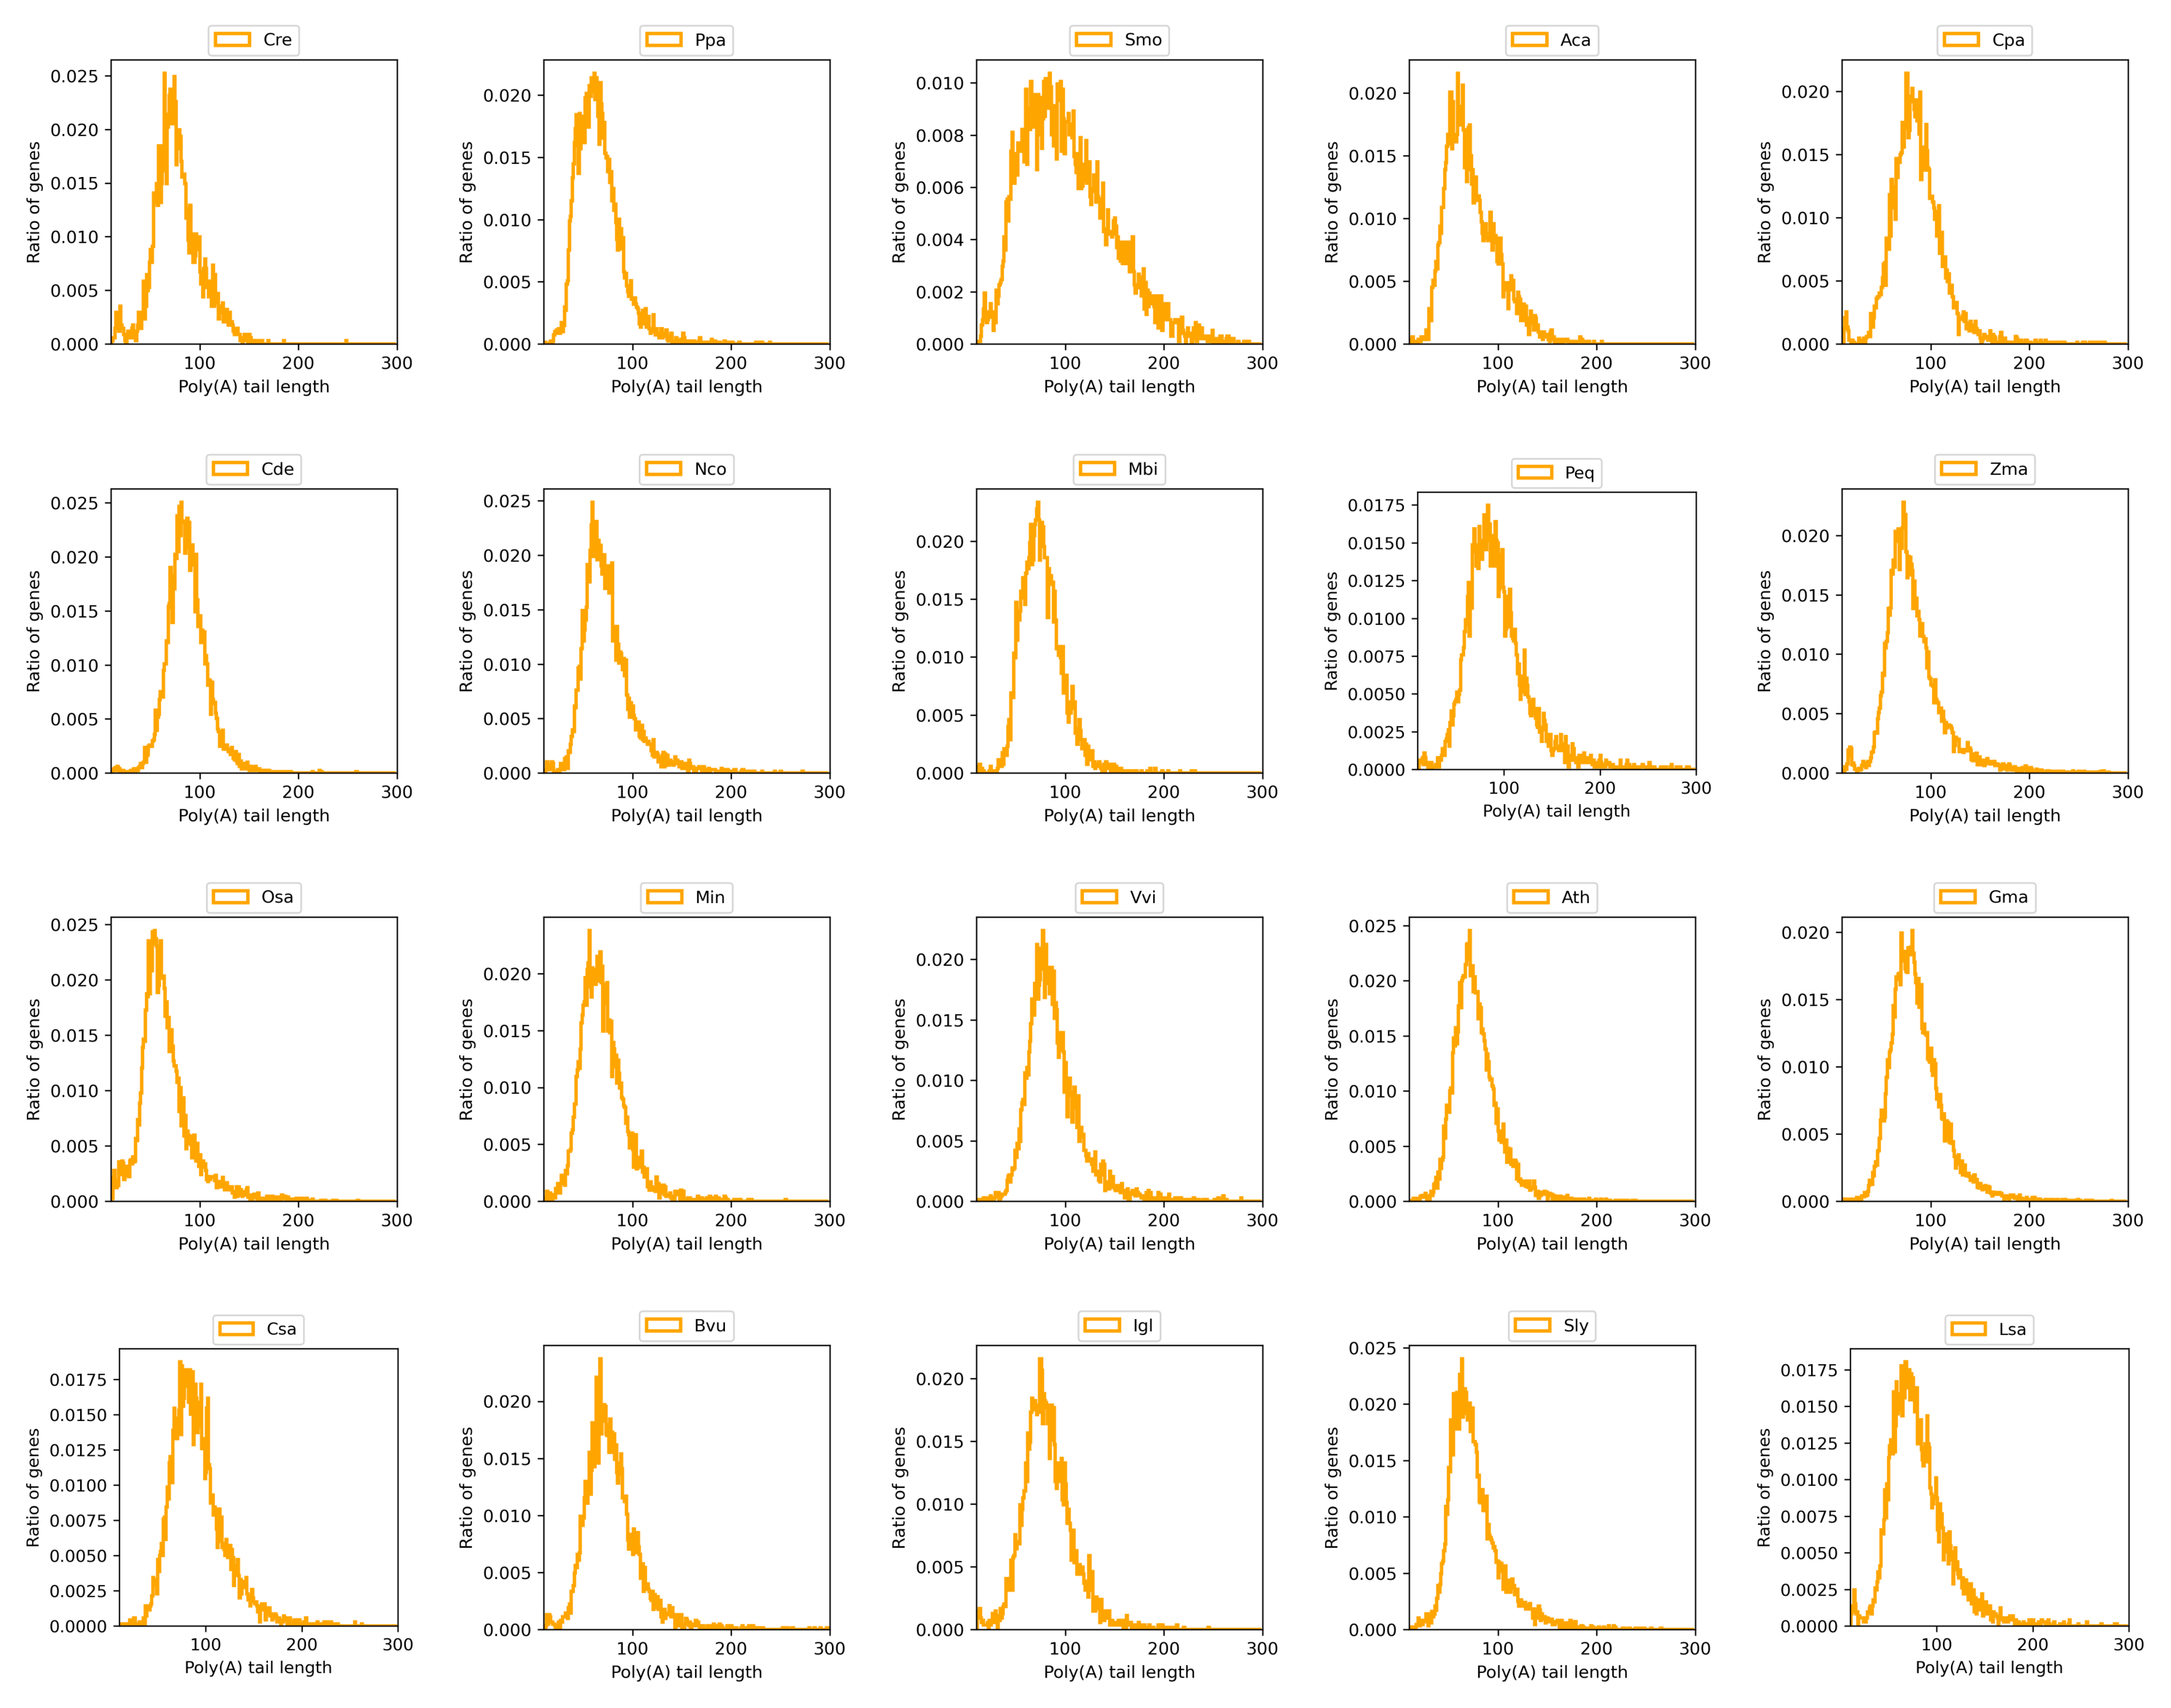

In [ ]:
os.chdir("03.stat/1.3_gene_hist/new")
# 图片文件名列表
image_files = ['01.Chrei.png',
'02.Phpat.png',
'03.Semoe.png',
'04.Adcap.png',
'05.Cypan.png',
'06.Cydeb.png',
'07.Nycol.png',
'08.Mabio.png',
'09.Phequ.png',
'10.Zemay.png',
'11.Orsat.png',
'12.Maint.png',
'13.Vivin.png',
'14.Artha.png',
'15.Glmax.png',
'16.Cusat.png',
'17.Bevul.png',
'18.Imgla.png',
'19.Solyc.png',
'20.Lasat.png',]

num_images = len(image_files)
num_rows = (num_images + 4) // 5  # 计算行数并向上取整

fig, axes = plt.subplots(num_rows, 5, figsize=(15, num_rows*3))
axes = axes.flatten()

for i, image_file in enumerate(image_files):
    img = plt.imread(image_file)
    axes[i].imshow(img)
    axes[i].axis('off')

# 如果最后一行不满5列，隐藏多余的子图
for j in range(len(image_files), num_rows*5):
    axes[j].axis('off')
    
plt.tight_layout()
plt.savefig("combined.png",bbox_inches='tight')
plt.show()

## 3.3 median 热图

In [ ]:
#定义函数，统计reads的尾长，按照长短的频次分布，进行频率的统计，并绘制成热图
#chatgpt
def plot_heatmap_read_length(x, 
                             bin_length=1,
                            min_length=10,
                            max_length=200,
                            cmap = "Blues", 
                            vmin=0,
                            vmax=None,
                            plot_legend=True,
                            title=None):
    
    tmp_bins = range(10, max_length+1, bin_length)
    x = x[(x>=min_length)]
    total_count = len(x)
    x = x[x<max_length]
    x = pd.Series(np.digitize(x, tmp_bins)).value_counts().sort_index()
    d = pd.DataFrame(x)
    d.columns = ["count"]
    d["length"] = d.index
    d = pd.DataFrame({"length": range(np.digitize(min_length, tmp_bins), 
                                      np.digitize(max_length-1, tmp_bins)+1, 
                                      1)}).merge(d, on="length", how="left").fillna(0)
    d.index = d["length"]
    d["count"] = d["count"]/total_count
    d_transposed = d[["count"]].T

    h = sns.clustermap(d_transposed, row_cluster=False, col_cluster=False, cmap=cmap, figsize=[2, 1], vmin=vmin, vmax=vmax)


    h.ax_heatmap.tick_params(right=False, bottom=False, labelright=False, labelbottom=False)
    #h.ax_heatmap.tick_params(bottom=False, labelbottom=False)
    h.ax_heatmap.set_xlabel("")
    h.ax_heatmap.set_ylabel("")
    if not plot_legend:
        h.cax.set_visible(False)
    if title is not None:
        ax = h.ax_heatmap  # Get the axes object       
        # Remove the original title
        ax.set_title("")
        # Determine the x and y coordinates for the new title
        x_coord = 1.05  # Adjust the value as needed
        y_coord = 0.5   # Adjust the value as needed       
        # Add the new title
        ax.text(x_coord, y_coord, title, transform=ax.transAxes, fontstyle='italic', fontsize=12, va='center')

In [ ]:
data=data_frames_median['Artha']

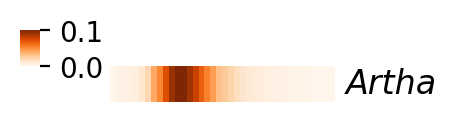

In [ ]:
plot_heatmap_read_length(data.all_median_polya,
                     bin_length=5,
                     cmap = "Oranges",
                     vmin=0,vmax=0.10,
                     title="Artha",
                     plot_legend=True,)
plt.savefig('03.stat/1.4_gene_heatmap/bin5/legend.svg', dpi=300, bbox_inches='tight')

In [ ]:
x_order = ['01.Chrei', '02.Phpat', '03.Semoe', '04.Adcap', '05.Cypan', '06.Cydeb', '07.Nycol', '08.Mabio', '09.Phequ', 
'10.Zemay', '11.Orsat', '12.Maint', '13.Vivin', '14.Artha', '15.Glmax', '16.Cusat', '17.Bevul', '18.Imgla', '19.Solyc', '20.Lasat']

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

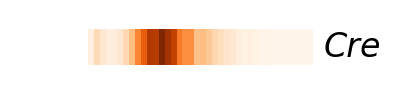

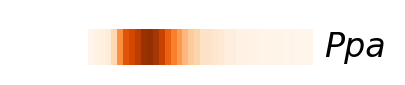

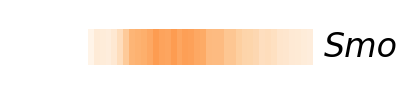

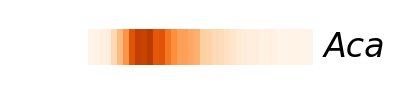

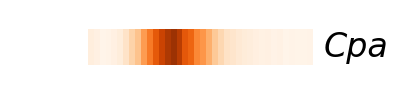

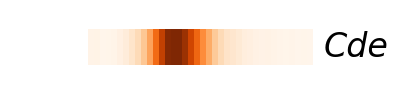

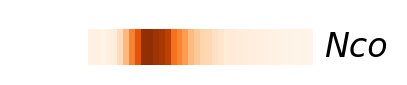

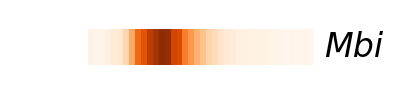

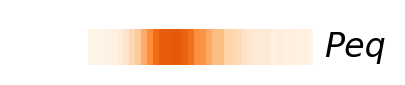

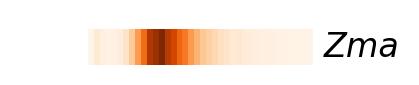

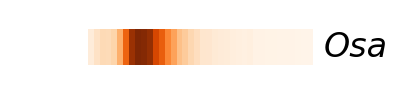

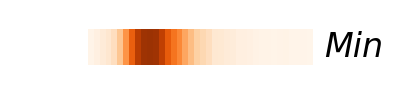

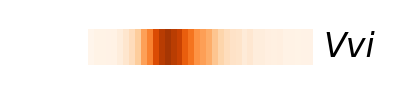

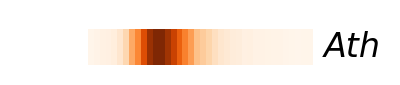

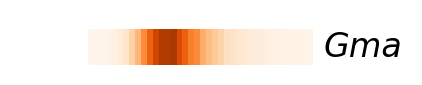

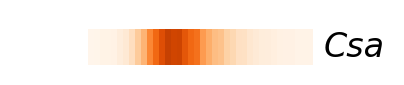

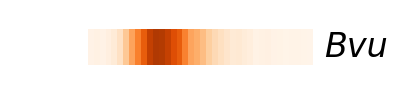

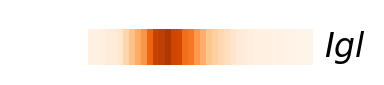

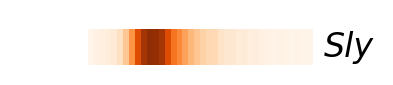

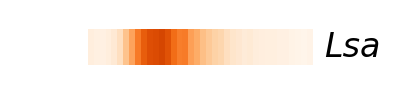

In [ ]:
for species in x_order:
    # 提取 key 名称
    key = species.split('.')[1]  # 提取 Chrei, Phpat 等
    if key in data_frames_median:
        df = data_frames_median[key]
        sample_name=''.join(key[i] for i in [0,2,3])
        plot_heatmap_read_length(df.all_median_polya,
                     vmin=0,vmax=0.10,
                     bin_length=5,
                     plot_legend=False,
                     cmap = "Oranges",
                     title=sample_name)
        plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15))  
        plt.savefig(f"/1.4_gene_heatmap/bin5/{species}.png", dpi=300, bbox_inches='tight') 

,value,key
0,79.61,Imgla
1,70.70,Imgla
2,85.83,Imgla
3,77.63,Imgla
4,146.38,Imgla


# 5.每个基因分布热图

## 5.1 定义函数

### bin=10nt

In [ ]:
def generate_polya_bin(df):
    #min_polya_length 10
    #min_count 15
    df = df.query('polya_length >= 10')
    cut_bins = list(range(10, 250, 10))
    tmp_length_bin = np.digitize(
        df.polya_length,
        cut_bins,
    )
    polya_bin = pd.crosstab(df.mRNA, tmp_length_bin)
    polya_bin = polya_bin.fillna(0)
    polya_bin = polya_bin.divide(polya_bin.sum(axis=1), axis=0)
    
    bin_sort_value = polya_bin.apply(lambda x: np.argsort(-x), axis=1)
    bin_sort_value.columns = ["o" + str(i) for i in range(len(polya_bin.columns))]
    bin_sort_value = bin_sort_value.reset_index()
    mRNA_median = df.groupby('mRNA').agg({"polya_length": [len, np.median]})
    mRNA_median = mRNA_median.reset_index()
    mRNA_median.columns = ["mRNA", "count", "median"]
    bin_sort_value = bin_sort_value.merge(mRNA_median, on="mRNA")
    bin_sort_value = bin_sort_value.sort_values(["o0", "median"])
    
    bin_sort_value = bin_sort_value.query('count >= 20')
    polya_bin = polya_bin.loc[list(bin_sort_value.mRNA), :]
    return (polya_bin, bin_sort_value)

In [ ]:
def real_plot_polya_clustermap(df, vmax=0.15, figsize=[4, 7], title=None):
    print(len(df))
    cg = sns.clustermap(df,  vmin=0, vmax=vmax, 
                        row_cluster=False, col_cluster=False,  method="average", 
                        cmap="RdYlBu_r", figsize=figsize)
    
    cg.ax_heatmap.tick_params(right=False, bottom=False, labelright=False, labelbottom=False)
    cg.ax_heatmap.set_xlabel("")
    cg.ax_heatmap.set_ylabel("")
    cg.cax.set_visible(False)
    cg.ax_heatmap.set_position([0.02,0.04,0.94,0.90])
    # 获取当前cg.ax_heatmap的位置并稍作调整以放置新的x轴
    pos = list(cg.ax_heatmap.get_position().bounds)
    pos[1] -= 0.01  # 将新x轴稍微移下一些
    ax_secondary = cg.fig.add_axes(pos, frame_on=False)
    
    # 设置新的x轴的属性
    ax_secondary.spines['top'].set_visible(False)
    ax_secondary.spines['right'].set_visible(False)
    ax_secondary.spines['left'].set_visible(False)
    ax_secondary.yaxis.set_visible(False)
    ax_secondary.set_facecolor("none") # 设置坐标轴背景为透明

    xticks_pos = [0, 4, 9, 14, 19, 24]
    xticks_labels = [10, 50, 100, 150, 200, 250]
    ax_secondary.set_xticks(xticks_pos)
    ax_secondary.set_xticklabels(xticks_labels)
    ax_secondary.xaxis.tick_bottom()
    ax_secondary.axhline(y=0, color='black', linestyle='solid')

    if title:
        cg.ax_heatmap.set_title(title, fontdict={'fontsize': '12'})
    
    return cg

### bin=20nt

In [ ]:
#函数1
def generate_polya_bin20(df):
    # 过滤掉polya_length小于10的行
    df = df.query('polya_length >= 10')
    
    # 定义切割bins的范围
    cut_bins = list(range(10, 250, 20))  # 确保cut_bins覆盖到250
    
    # 使用np.digitize对polya_length进行分bin
    tmp_length_bin = np.digitize(df.polya_length, cut_bins)
    
    # 创建crosstab并进行归一化处理
    polya_bin = pd.crosstab(df.pepid, tmp_length_bin)
    polya_bin = polya_bin.fillna(0)
    polya_bin = polya_bin.divide(polya_bin.sum(axis=1), axis=0)
    
    # 确保polya_bin包含所有的bin
    all_bins = np.arange(1, len(cut_bins) + 1)
    polya_bin = polya_bin.reindex(columns=all_bins, fill_value=0)
    
    bin_sort_value = polya_bin.apply(lambda x: np.argsort(-x), axis=1)
    bin_sort_value.columns = ["o" + str(i) for i in range(len(polya_bin.columns))]
    bin_sort_value = bin_sort_value.reset_index()
    mRNA_median = df.groupby('pepid').agg({"polya_length": [len, np.median]})
    mRNA_median = mRNA_median.reset_index()
    mRNA_median.columns = ["pepid", "count", "median"]
    bin_sort_value = bin_sort_value.merge(mRNA_median, on="pepid")
    bin_sort_value = bin_sort_value.sort_values(["o0", "median"])
    
    bin_sort_value = bin_sort_value.query('count >= 20')
    polya_bin = polya_bin.loc[list(bin_sort_value.pepid), :]
    return (polya_bin, bin_sort_value)

In [ ]:
def real_plot_polya_clustermap20(df, vmax=0.4, figsize=[4, 7], title=None):
    print(len(df))
    cg = sns.clustermap(df,  vmin=0, vmax=vmax, 
                        row_cluster=False, col_cluster=False,  method="average", 
                        cmap="RdYlBu_r", figsize=figsize)
    
    cg.ax_heatmap.tick_params(right=False, bottom=False, labelright=False, labelbottom=False)
    cg.ax_heatmap.set_xlabel("")
    cg.ax_heatmap.set_ylabel("")
    cg.cax.set_visible(False)
    cg.ax_heatmap.set_position([0.02,0.04,0.94,0.90])
    # 获取当前cg.ax_heatmap的位置并稍作调整以放置新的x轴
    pos = list(cg.ax_heatmap.get_position().bounds)
    pos[1] -= 0.01  # 将新x轴稍微移下一些
    ax_secondary = cg.fig.add_axes(pos, frame_on=False)
    
    # 设置新的x轴的属性
    ax_secondary.spines['top'].set_visible(False)
    ax_secondary.spines['right'].set_visible(False)
    ax_secondary.spines['left'].set_visible(False)
    ax_secondary.yaxis.set_visible(False)
    ax_secondary.set_facecolor("none") # 设置坐标轴背景为透明

    xticks_pos = [0,12]
    xticks_labels = [10, 250]
    ax_secondary.set_xticks(xticks_pos)
    ax_secondary.set_xticklabels(xticks_labels,fontdict={'fontsize': '30'})
    ax_secondary.xaxis.tick_bottom()
    ax_secondary.axhline(y=0, color='black', linestyle='solid')

    if title:
        cg.ax_heatmap.set_title(title, fontdict={'fontsize': '30'})
    
    return cg

## 5.1 基因的分布

In [ ]:
def lp(pkl):
    with open(pkl, "rb") as fh:
        data = pickle.load(fh)
    return data

In [ ]:
data_frames=lp("/data/Zhaijx/cheny/project/04.polyA_evo/12.all_pep/pepid_polya/all_species.pep.pickle")

In [ ]:
species_order = ['01.Chrei',
'02.Phpat',
'03.Semoe',
'04.Adcap',
'05.Cypan',
'06.Cydeb',
'07.Nycol',
'08.Mabio',
'09.Phequ',
'10.Zemay',
'11.Orsat',
'12.Maint',
'13.Vivin',
'14.Artha',
'15.Glmax',
'16.Cusat',
'17.Bevul',
'18.Imgla',
'19.Solyc',
'20.Lasat']


Chrei
3535
Phpat
8117
Semoe
9876
Adcap
5507
Cypan
6851
Cydeb
8293
Nycol
6816
Mabio
5370
Phequ
6543
Zemay
15799
Orsat
10960
Maint
7017
Vivin
6930
Artha
11208
Glmax
17807
Cusat
7024
Bevul
6249
Imgla
5593
Solyc
8689
Lasat
7297


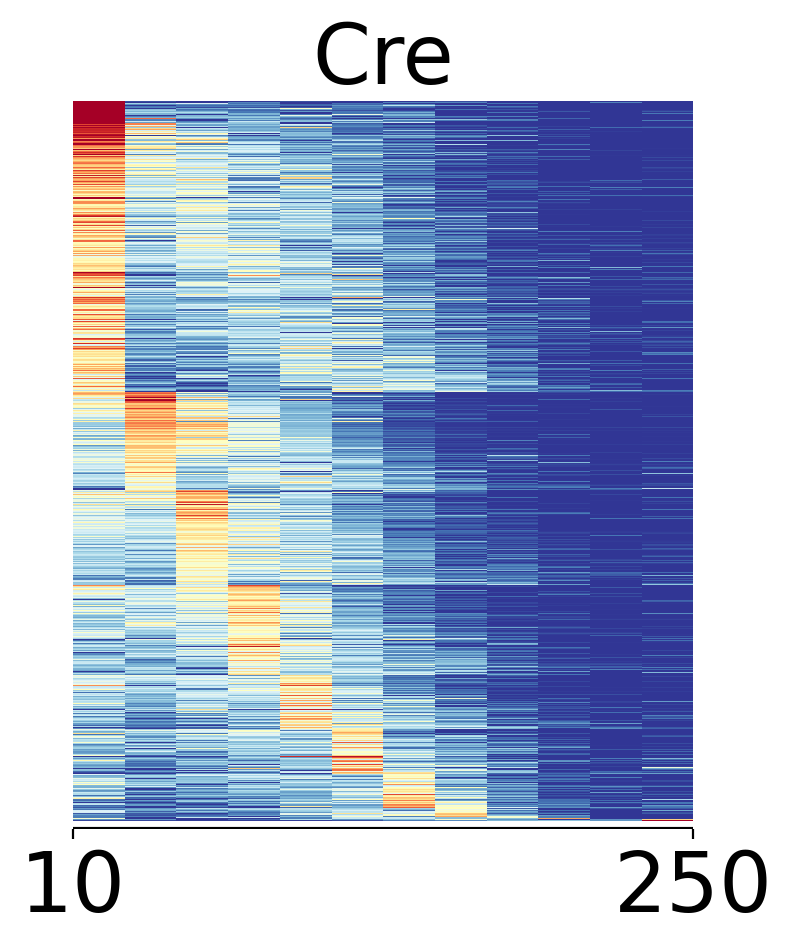

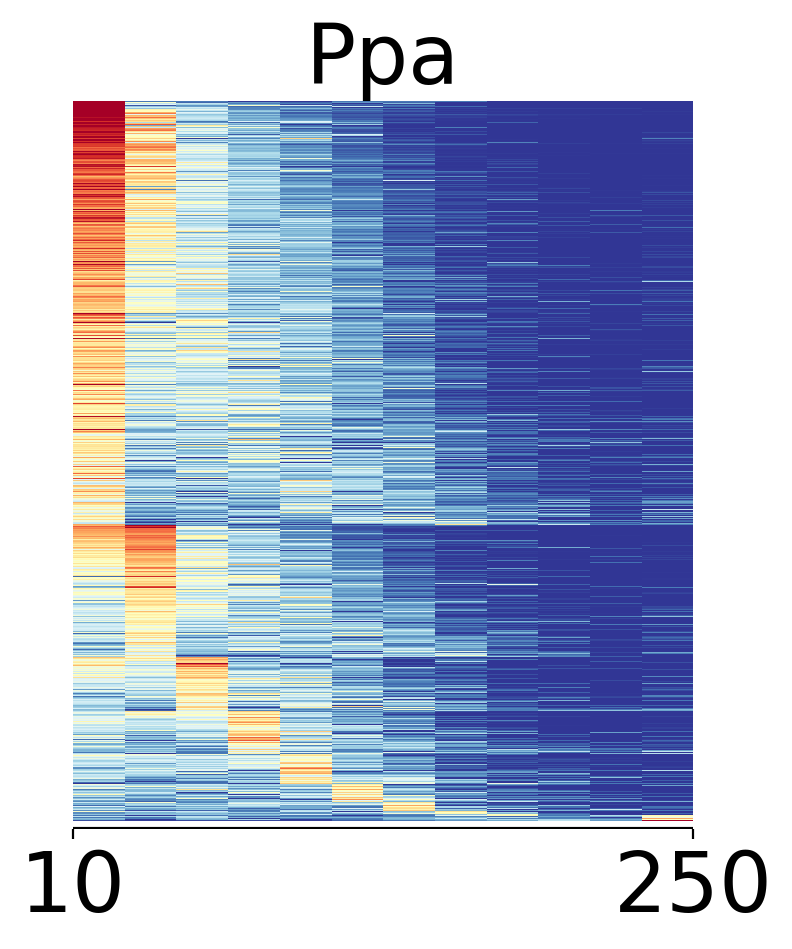

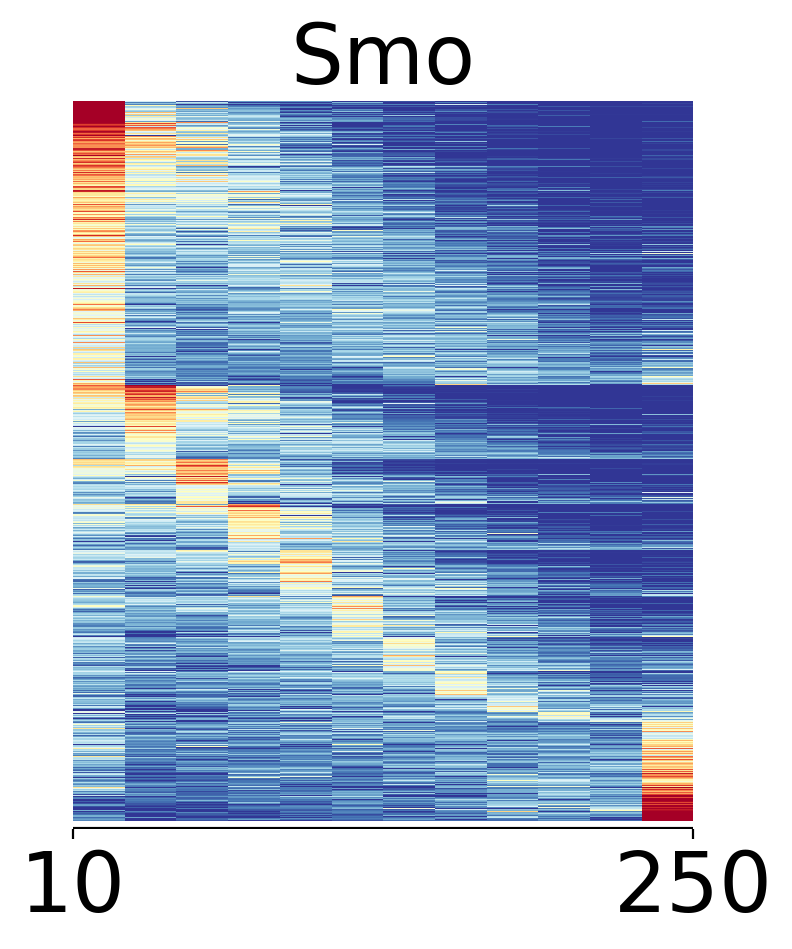

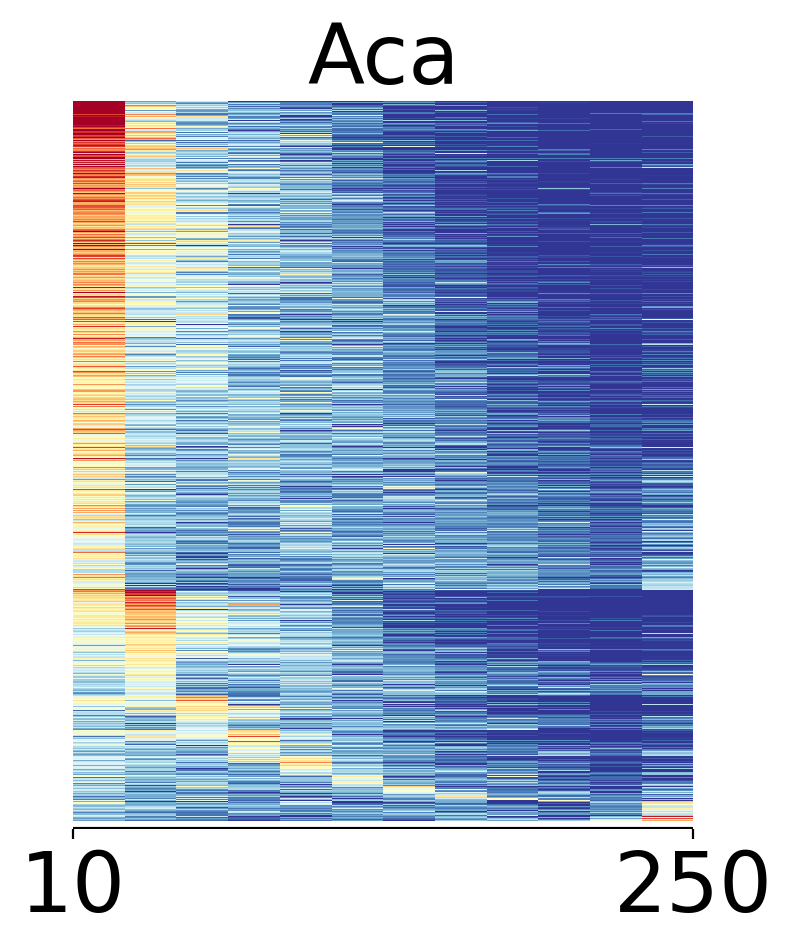

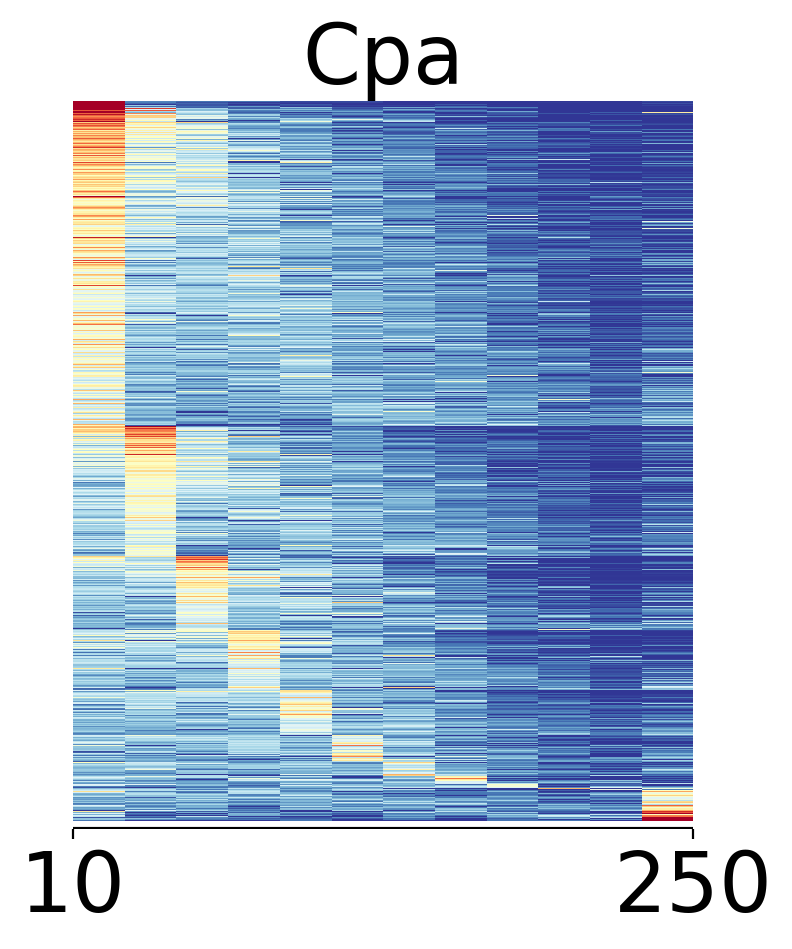

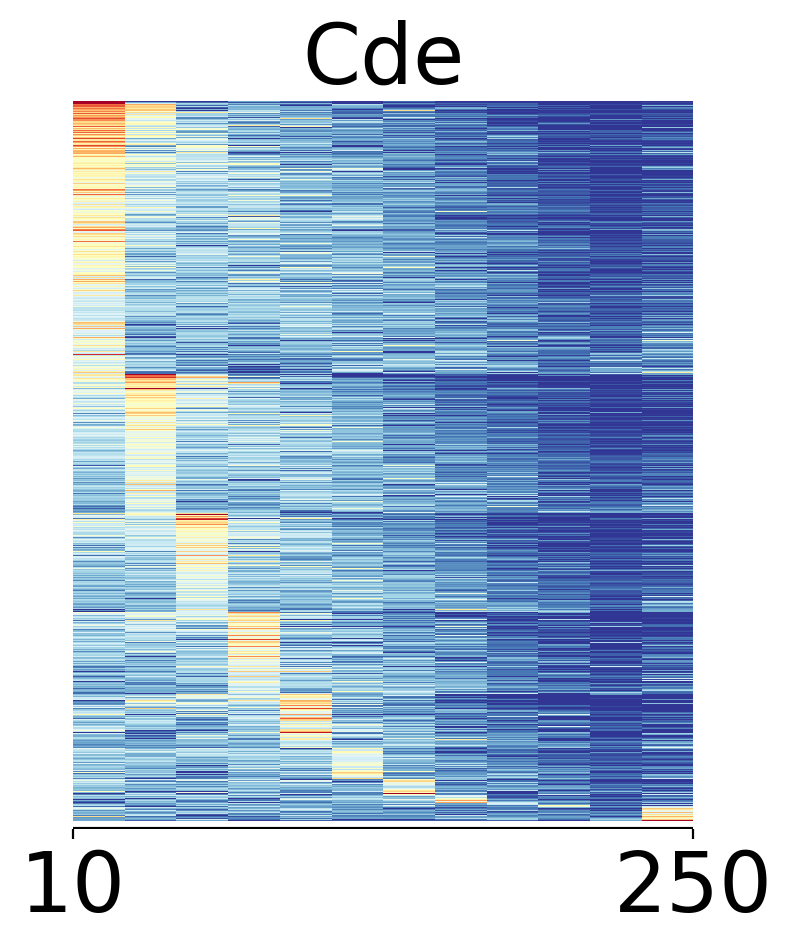

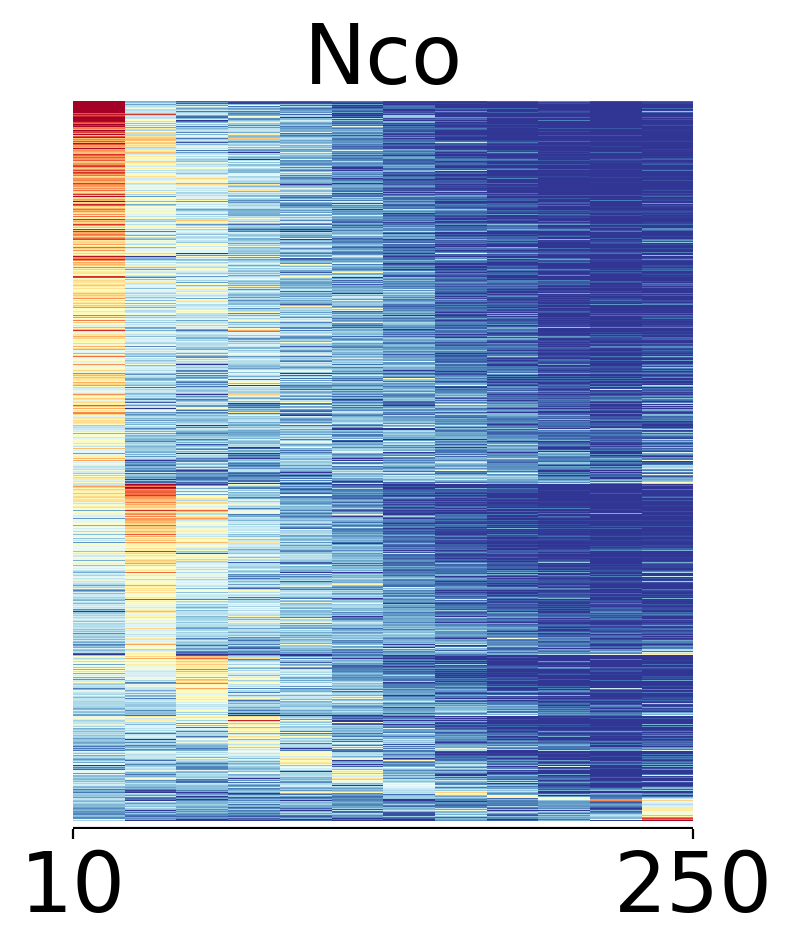

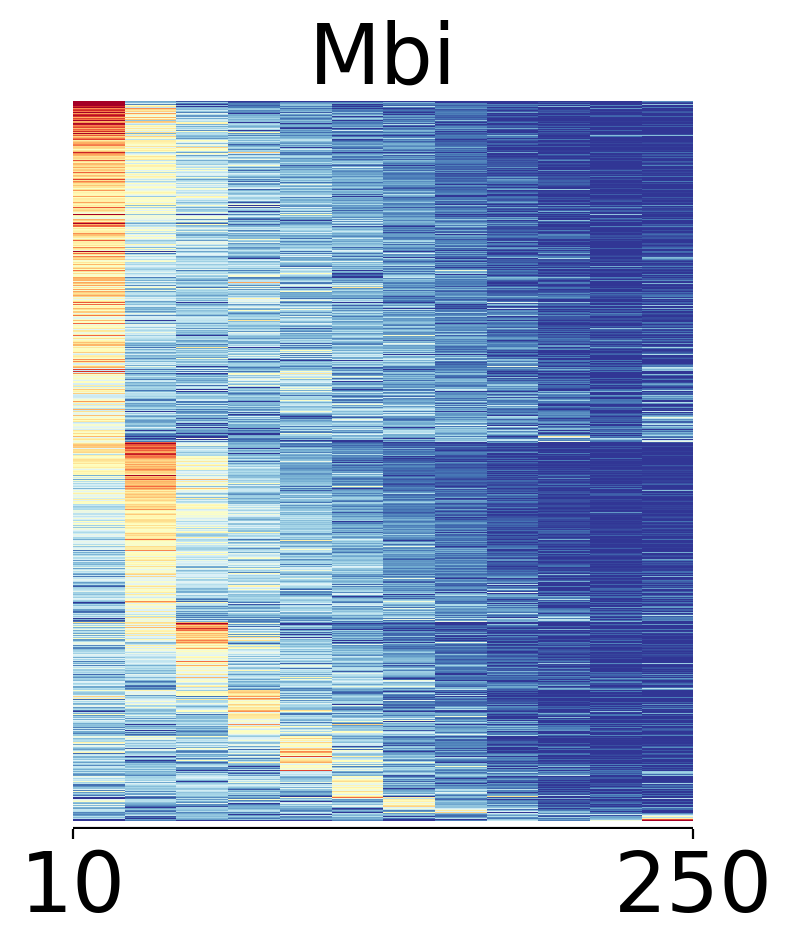

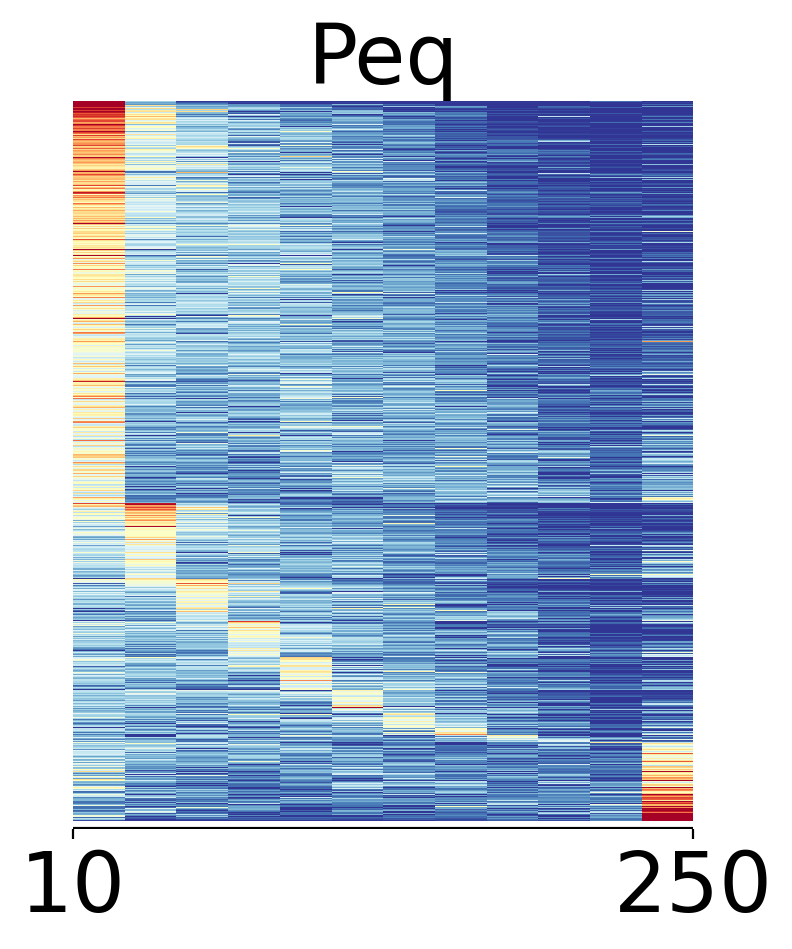

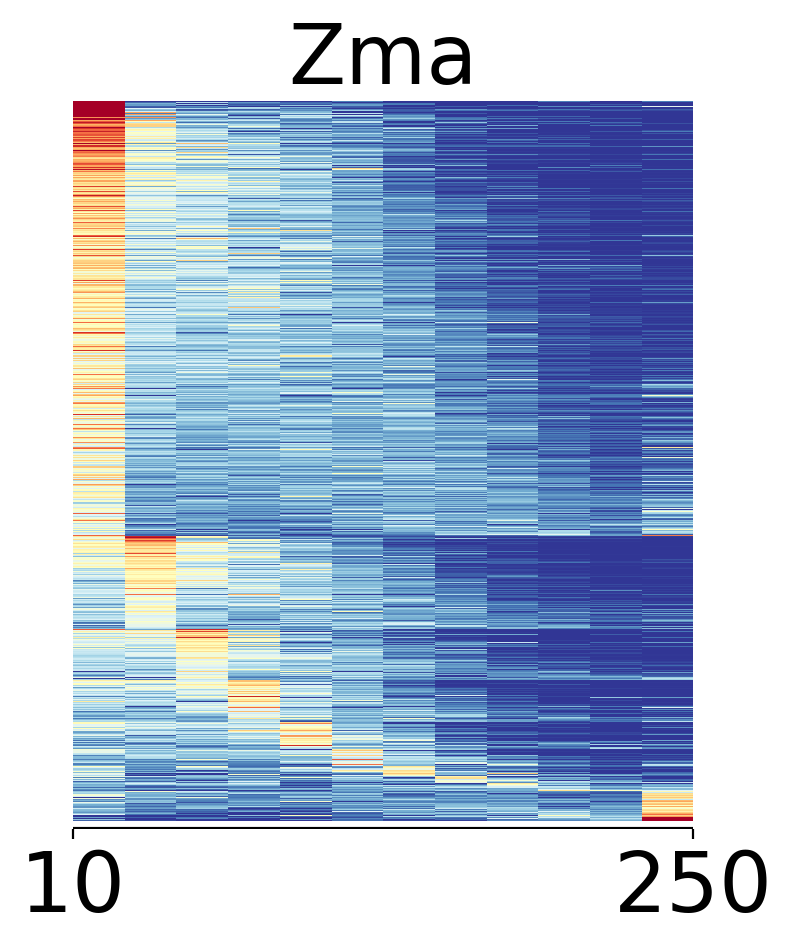

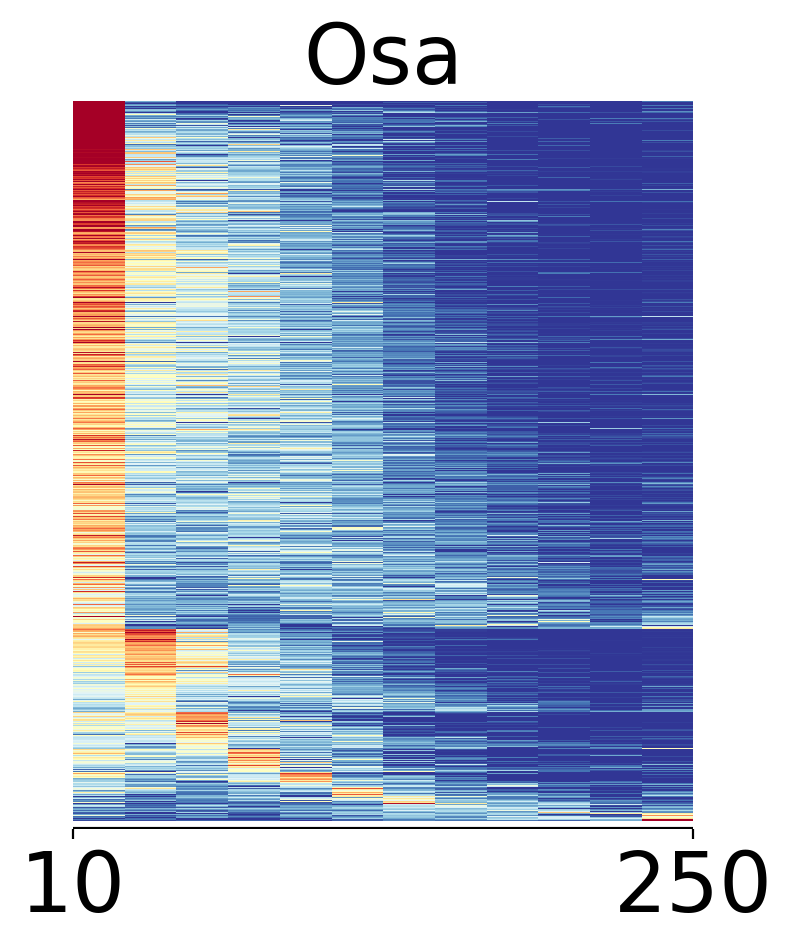

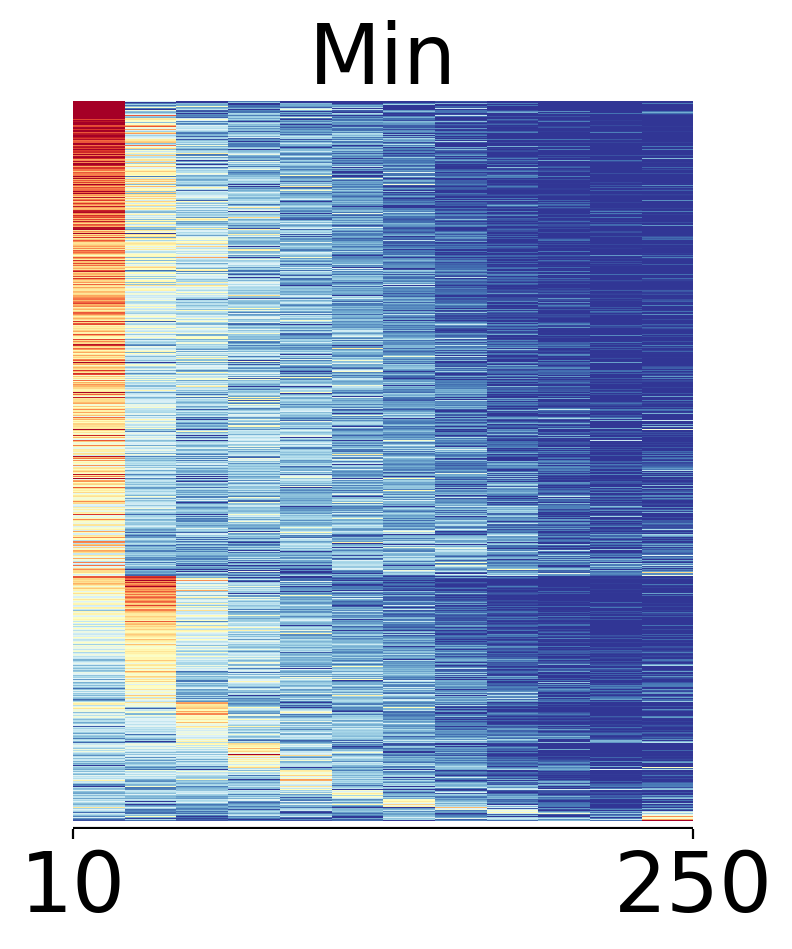

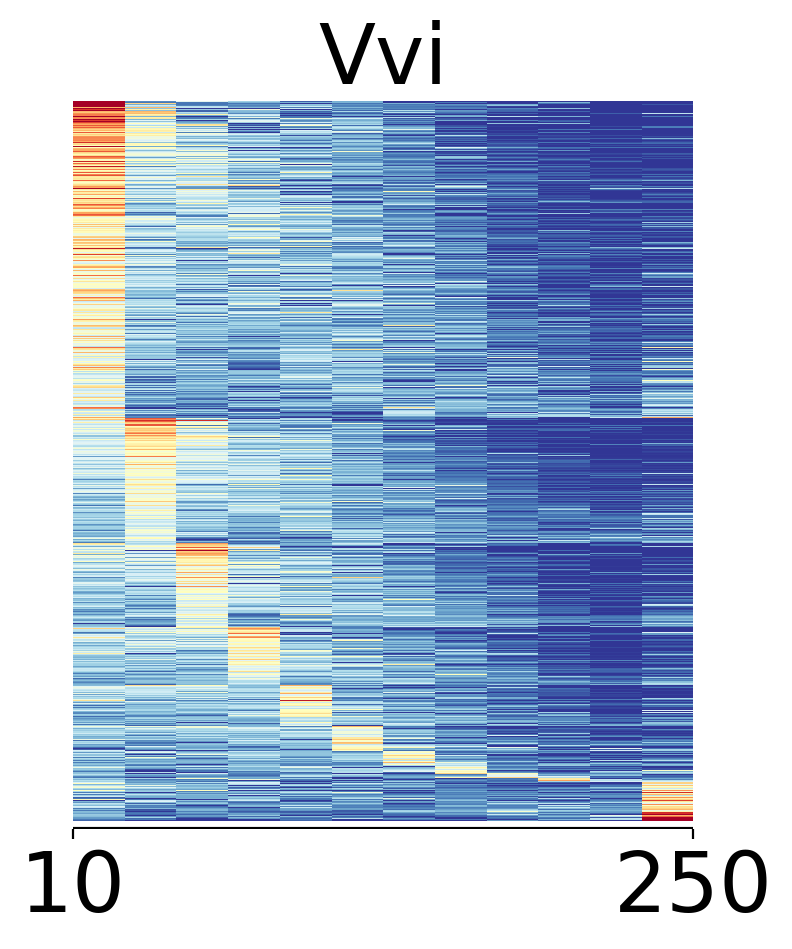

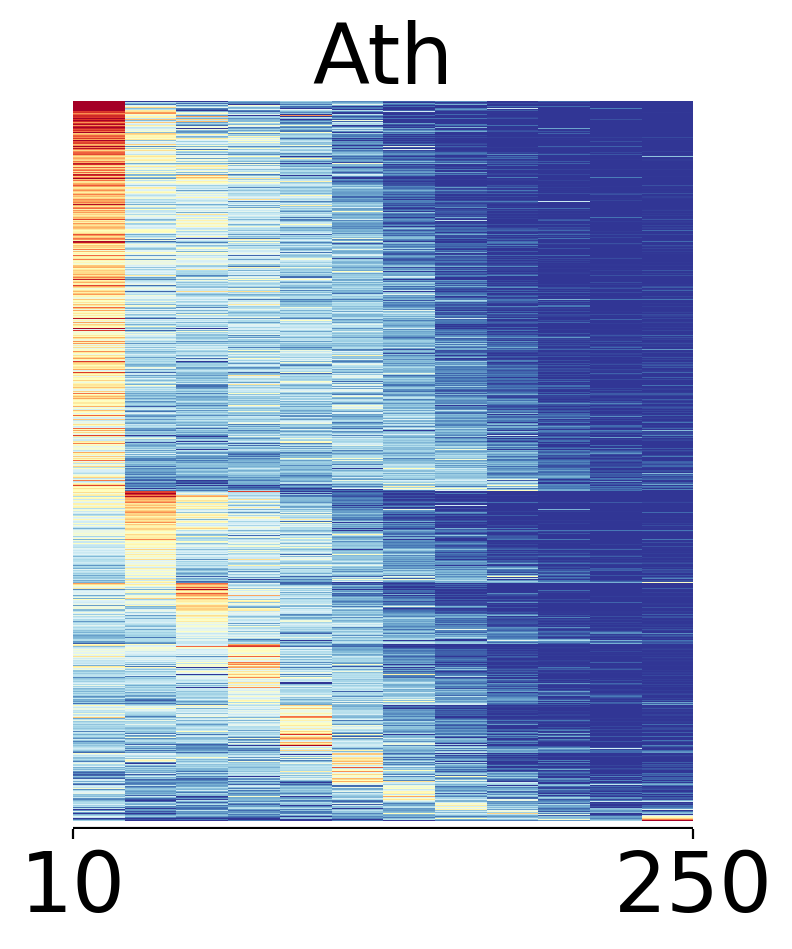

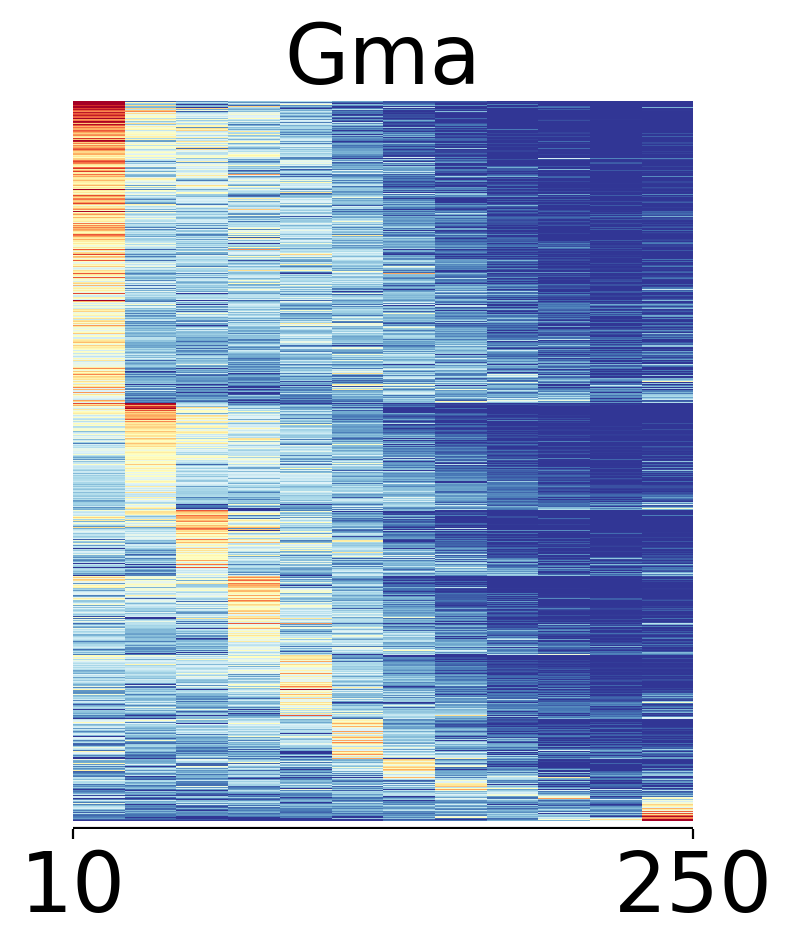

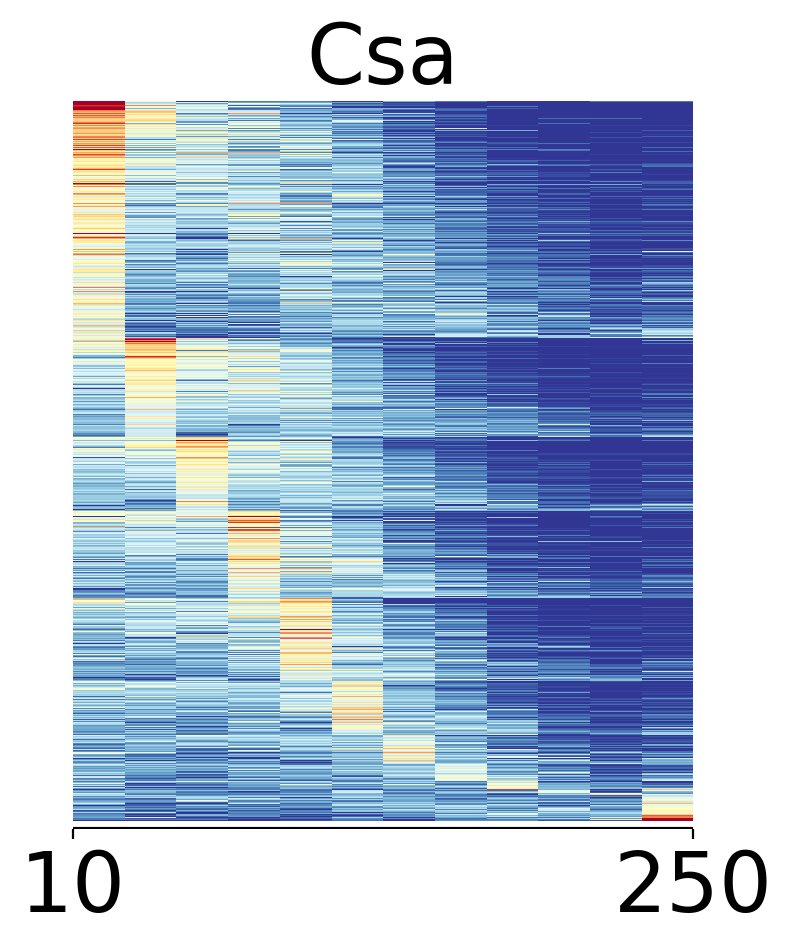

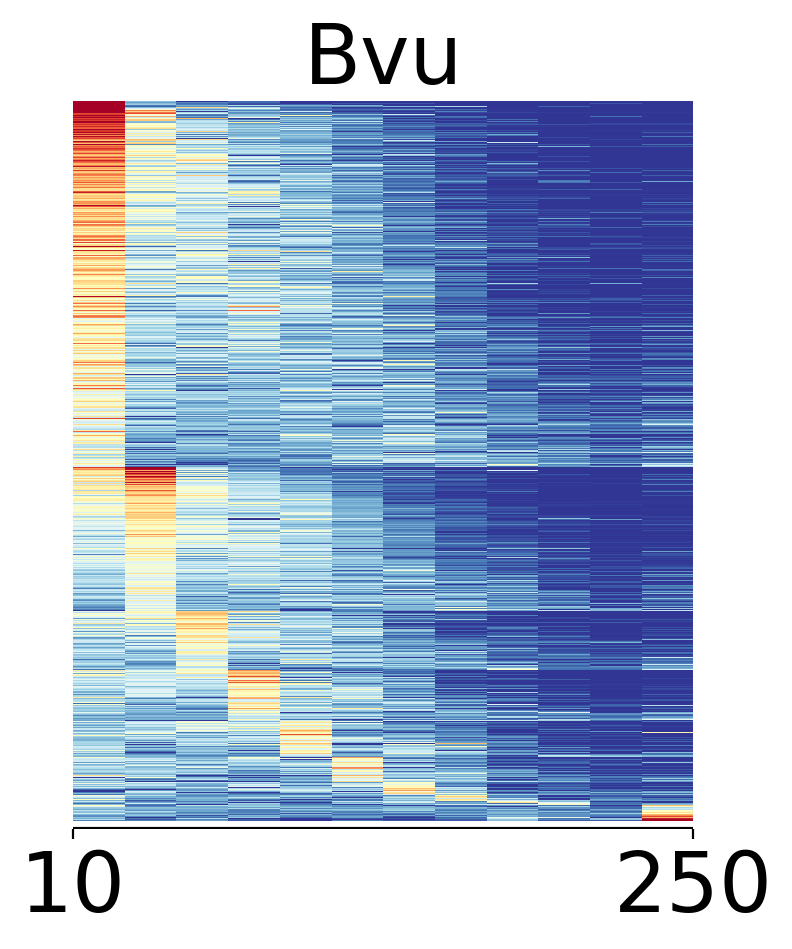

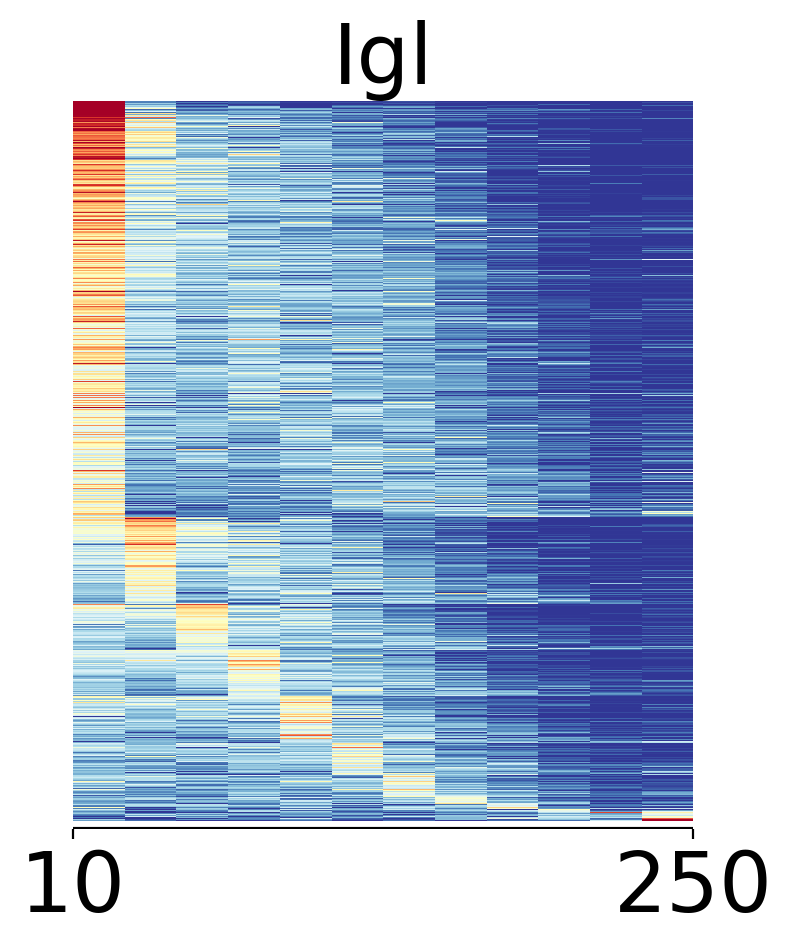

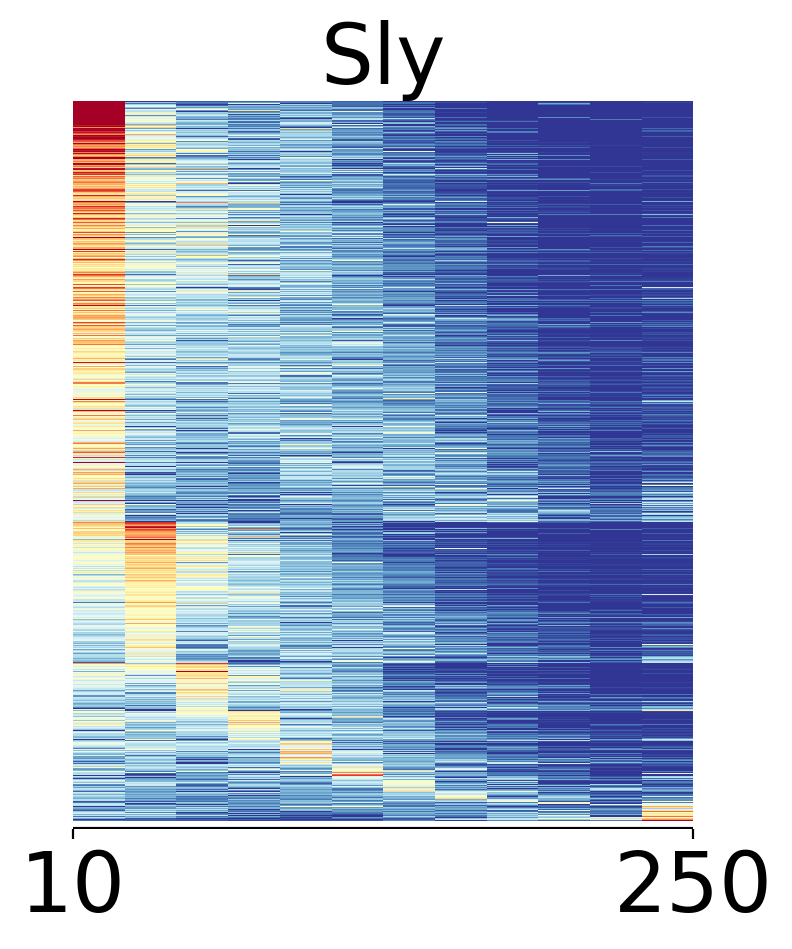

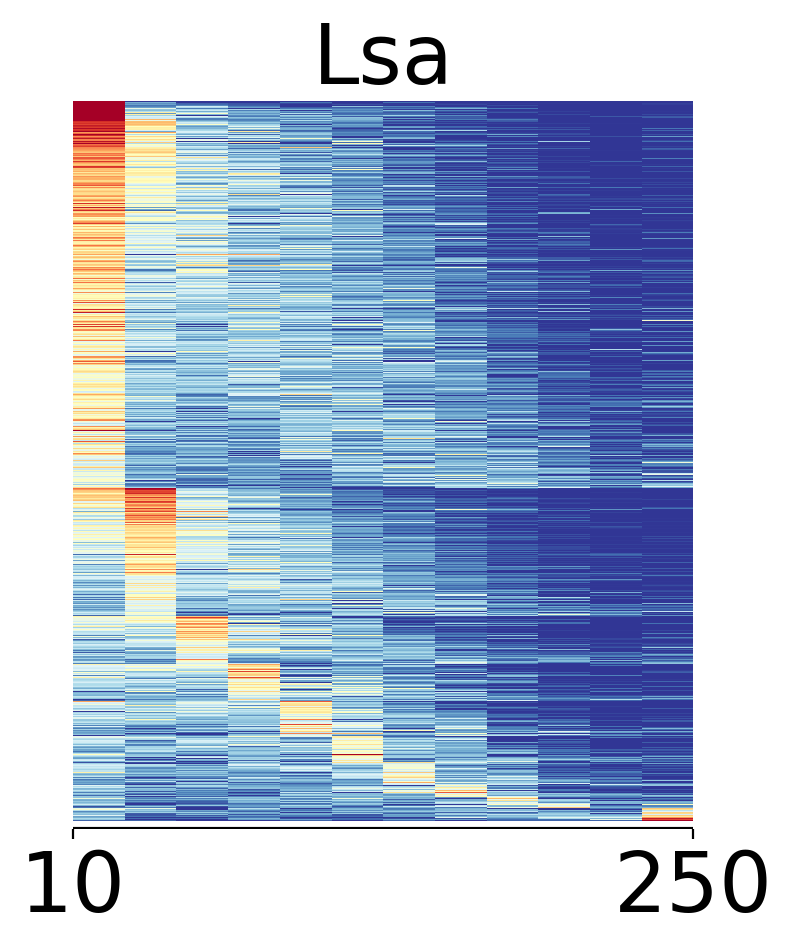

In [ ]:
for species_name in species_order:
    species=species_name[3:]
    print (species)
    species_data = data_frames.get(species)
    polya_bin, bin_sort_value = generate_polya_bin20(species_data)
    length = len(polya_bin)
    string="N = {}".format(length)
    title=''.join(species[i] for i in [0,2,3])
    real_plot_polya_clustermap20(polya_bin, figsize=[3.3, 4], title=title)
    plt.savefig(f"/1.6_gene_polya_length/bin20/{species_name}.png", dpi=300,bbox_inches='tight')   

## 5.2 拼接起来

In [ ]:
from PIL import Image
import os

# 更改工作目录
os.chdir("/1.6_gene_polya_length/bin20")

# 图片文件名
image_files = [
    '01.Chrei.png',
    '02.Phpat.png',
    '03.Semoe.png',
    '04.Adcap.png',
    '05.Cypan.png',
    '06.Cydeb.png',
    '07.Nycol.png',
    '08.Mabio.png',
    '09.Phequ.png',
    '10.Zemay.png',
    '11.Orsat.png',
    '12.Maint.png',
    '13.Vivin.png',
    '14.Artha.png',
    '15.Glmax.png',
    '16.Cusat.png',
    '17.Bevul.png',
    '18.Imgla.png',
    '19.Solyc.png',
    '20.Lasat.png',
    '20.Lasat.png'
]

# 每组拼接的图片数量
images_per_group = 7

# 计算总共可以拼接多少组图片
num_groups = len(image_files) // images_per_group + (1 if len(image_files) % images_per_group else 0)

for i in range(num_groups):
    # 起始索引和结束索引
    start_index = i * images_per_group
    end_index = min((i + 1) * images_per_group, len(image_files))

    # 按照起始索引和结束索引截取图片文件名
    image_files_group = image_files[start_index:end_index]

    # 获取第一张图片的宽度和高度
    if image_files_group:  # 确保列表不为空
        image = Image.open(image_files_group[0])
        image_width, image_height = image.size
    else:
        continue  # 如果没有图片，则跳过本次循环

    # 创建一张新的空白拼接图，宽度为每组图片数量乘以单张图片宽度，高度为单张图片高度
    combined_image = Image.new("RGB", (image_width * len(image_files_group), image_height))

    x_offset = 0

    # 拼接图像
    for image_file in image_files_group:
        # 打开图片
        image = Image.open(image_file)

        # 将图片粘贴到拼接图上
        combined_image.paste(image, (x_offset, 0))

        # 更新x偏移量
        x_offset += image_width

    # 保存拼接图像
    combined_image.save(f"combined{i+1:02d}.png")

# 10 质体基因组

In [7]:
data_folder = "/data/Zhaijx/cheny/project/04.polyA_evo/02.new_map/"
samples_file = "/data/Zhaijx/cheny/project/04.polyA_evo/08.cp_mt/sample_species.txt"
output_dir = "/data/Zhaijx/cheny/project/04.polyA_evo/08.cp_mt/"

try:
    samples = pd.read_csv(samples_file, sep="\t", header=None)
except FileNotFoundError:
    print(f"Error: Sample file not found at {samples_file}")
    exit()

os.makedirs(output_dir, exist_ok=True)

In [8]:
samples

,0,1,2,3,4,5,6,7
0,01.cucumber,Cucumis sativus,22491,16.cucumber,20,45,NC_007144.1,NC_016005.1
1,02.phalaenopsis,Phalaenopsis equestris,20970,09.phalaenopsis,20,45,NC_017609.1,-
2,03.chlamydomonas,Chlamydomonas reinhardtii,17742,01.chlamydomonas,40,65,NC_005353.1,NC_001638.1
3,04.adiantum,Adiantum caplillusveneris,31244,04.adiantum,20,45,NC_004766.1,-
4,05.physcomitrium,Physcomitrium patens,22457,02.physcomitrium,20,45,NC_005087.1,NC_007945.1
5,#06.tripterygium,Tripterygium wilfordii,33146,17.tripterygium,20,45,NC_061612.1,NC_082972.1
6,07.selaginella,Selaginella moellendorffii,35448,03.selaginella,20,45,NC_013086.1,NW_003314435.1
7,08.macadamia,Macadamia integrifolia,32433,12.macadamia,20,45,NC_025288.1,NC_058888.1
8,09.nymphaea,Nymphaea colorata,21850,07.nymphaea,20,45,NC_057562.1,NC_037468.1
9,10.solanum,Solanum lycopersicum,28468,20.solanum,20,45,NC_007898.3,NC_035963.1


In [9]:
all_species_data = pd.DataFrame()

for index, row in samples.iterrows():
    sample = row[0]
    gene_number = row[2]
    data_file_path = os.path.join(data_folder, sample, "merge/merge.readinfo.merge.txt")
    sample_name = row[1]
    sample_new = row[3]
    cp_genome = str(row[6])
    mt_genome = str(row[7])

    try:
        data = pd.read_csv(data_file_path, sep="\t", na_values="NA")
    except FileNotFoundError:
        print(f"Warning: Data file not found at {data_file_path} for sample {sample}")
        continue

    if cp_genome != "-" or mt_genome != "-":
        has_cp_mt_data = any(data['chr'] == cp_genome) or any(data['chr'] == mt_genome)

        if has_cp_mt_data:
            data['group'] = 'nuclear'  # Default group

            if cp_genome != "-":
                data.loc[data['chr'] == cp_genome, 'group'] = 'chlorplast'
            if mt_genome != "-":
                data.loc[data['chr'] == mt_genome, 'group'] = 'mitochondrial'

            filtered_data = data[data['polya_length'] > 10].copy()
            filtered_data = filtered_data[['group', 'polya_length']]
            filtered_data['species'] = sample_name

            all_species_data = pd.concat([all_species_data, filtered_data], ignore_index=True)


/tmp/ipykernel_26882/854317827.py:13: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_file_path, sep="\t", na_values="NA")
/tmp/ipykernel_26882/854317827.py:13: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_file_path, sep="\t", na_values="NA")
/tmp/ipykernel_26882/854317827.py:13: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_file_path, sep="\t", na_values="NA")
/tmp/ipykernel_26882/854317827.py:13: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_file_path, sep="\t", na_values="NA")
/tmp/ipykernel_26882/854317827.py:13: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_file_path, sep="\t", na_val

/tmp/ipykernel_26882/854317827.py:13: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_file_path, sep="\t", na_values="NA")
/tmp/ipykernel_26882/854317827.py:13: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_file_path, sep="\t", na_values="NA")
/tmp/ipykernel_26882/854317827.py:13: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_file_path, sep="\t", na_values="NA")
/tmp/ipykernel_26882/854317827.py:13: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_file_path, sep="\t", na_values="NA")
/tmp/ipykernel_26882/854317827.py:13: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_file_path, sep="\t", na_val

/tmp/ipykernel_26882/854317827.py:13: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_file_path, sep="\t", na_values="NA")
/tmp/ipykernel_26882/854317827.py:13: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_file_path, sep="\t", na_values="NA")
/tmp/ipykernel_26882/854317827.py:13: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_file_path, sep="\t", na_values="NA")


In [10]:
data_file_path = "/data/Zhaijx/cheny/project/04.polyA_evo/02.new_map/20.arabidopsis/ara_leaf_20210705/results/ara_leaf_20210705.read.info.txt"
data = pd.read_csv(data_file_path, sep="\t", na_values="NA")


/tmp/ipykernel_26882/1480306680.py:2: DtypeWarning: Columns (1,30) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_file_path, sep="\t", na_values="NA")


In [11]:
cp_genome = "Pt"
mt_genome = "Mt"
sample_name="Arabidopsis thaliana"
data['group'] = 'nuclear'
data.loc[data['chr'] == cp_genome, 'group'] = 'chlorplast'
data.loc[data['chr'] == mt_genome, 'group'] = 'mitochondrial'
filtered_data = data[data['polya_length'] > 10].copy()
filtered_data = filtered_data[['group', 'polya_length']]
filtered_data['species'] = sample_name
all_species_data = pd.concat([all_species_data, filtered_data], ignore_index=True)

In [15]:
all_species_data = all_species_data[all_species_data['polya_length'] < 350]

In [13]:
def create_short_species_name(species_string):
    """
    从物种名称字符串中提取缩写：第一个单词的首字母 + 第二个单词的前两个字母。
    """
    parts = species_string.split()
    if len(parts) >= 2:
        part1 = parts[0]
        part2 = parts[1]
        return part1[0] + part2[:2]
    elif len(parts) == 1:
        return parts[0][:3] # 如果只有一个单词，取前三个字母
    else:
        return ""

# 应用该函数到 'species' 列，创建新的 'species_short' 列
all_species_data['species_short'] = all_species_data['species'].apply(create_short_species_name)


In [14]:
sample_size = 100000
sampled_data = all_species_data.groupby(['species'], group_keys=False).apply(
    lambda x: x.sample(min(len(x), sample_size))
)

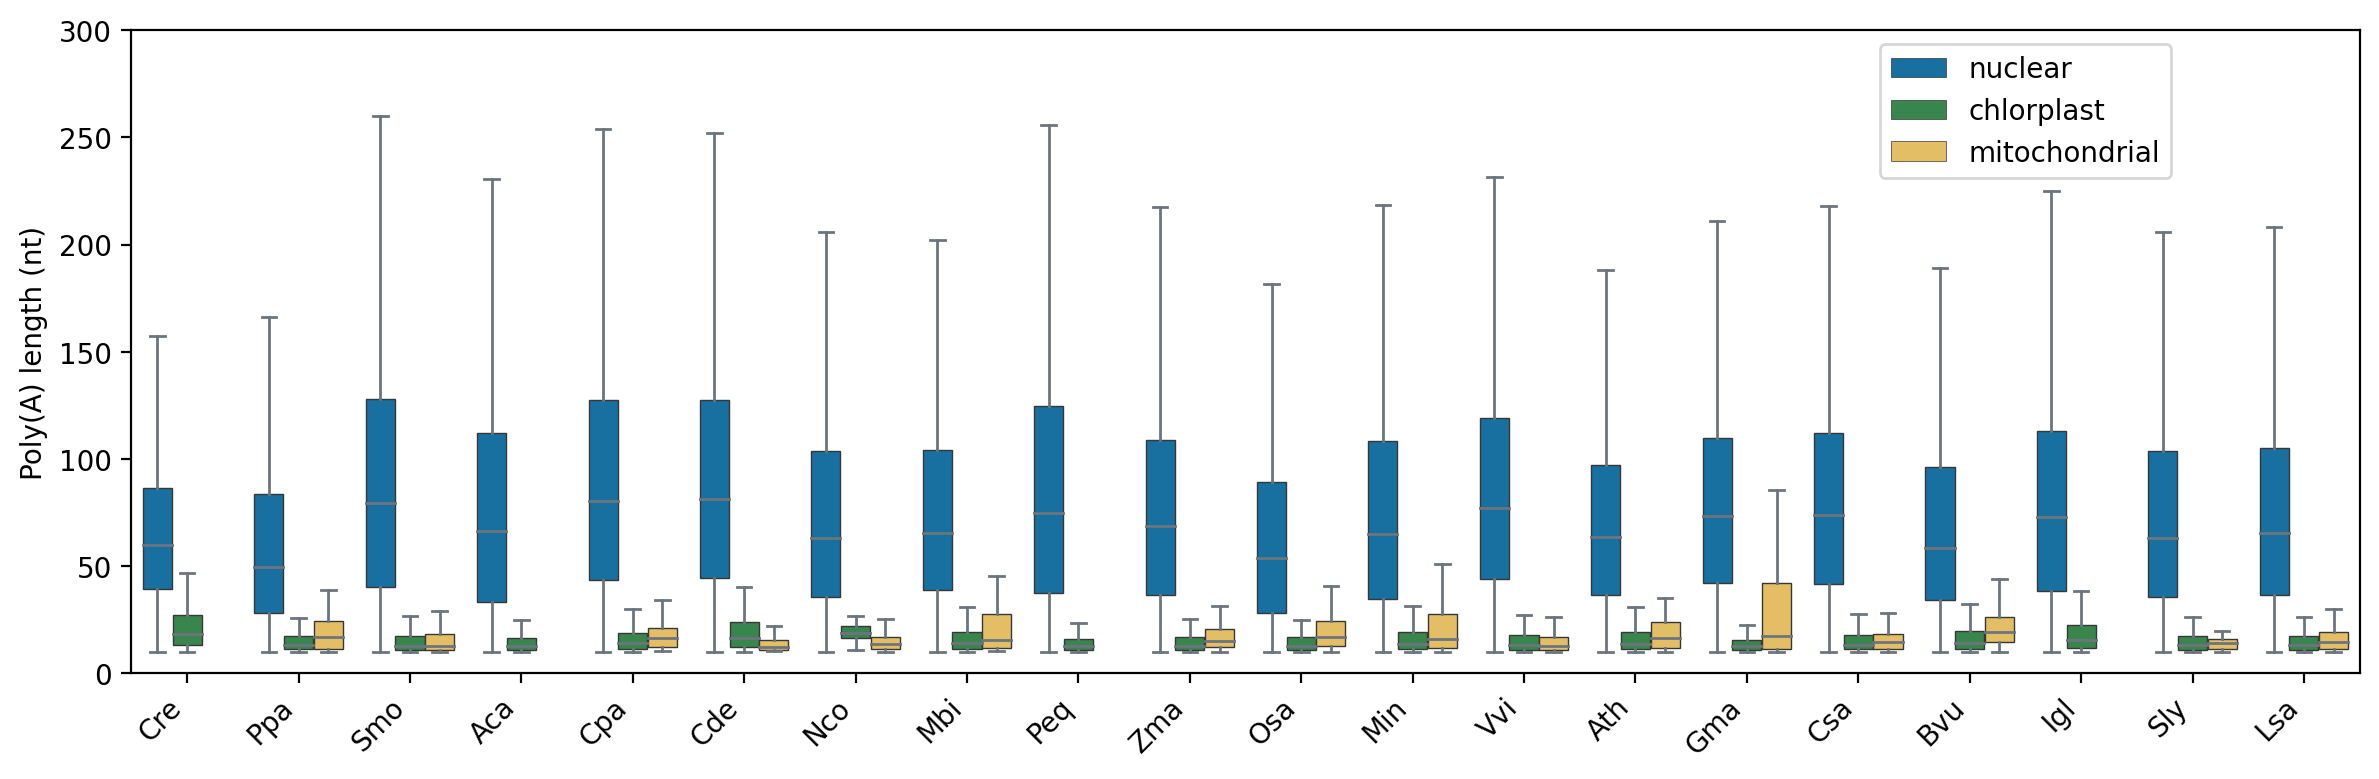

In [16]:
x_order = ['Cre', 'Ppa', 'Smo', 'Aca', 'Cpa', 'Cde', 'Nco', 'Mbi', 'Peq', 'Zma', 'Osa', 'Min', 'Vvi', 'Ath', 'Gma', 'Csa', 'Bvu', 'Igl', 'Sly', 'Lsa']
plt.figure(figsize=(12, 4))
sns.boxplot(x='species_short', y='polya_length', hue='group', data=sampled_data,
            palette={"nuclear": "#0077b6", "mitochondrial": "#f9c74f", "chlorplast": "#2b9348"},
            order=x_order, showfliers=False,linewidth=0.5,
    whiskerprops=dict(linewidth=1, color='#6c757d'),
    capprops=dict(linewidth=1, color='#6c757d'),
    medianprops=dict(linewidth=1, color='#6c757d'))
plt.xlabel("")
plt.ylabel("Poly(A) length (nt)")
plt.title("")
plt.xticks(rotation=45, ha='right')
plt.ylim(0,300)
plt.legend(title='',loc='upper center', bbox_to_anchor=(0.85, 1)) 
plt.rcParams['svg.fonttype']='none'
plt.savefig("/data/Zhaijx/cheny/project/04.polyA_evo/08.cp_mt/new_mt_cp.svg",format='svg')
plt.tight_layout()
plt.show()